<a href="https://www.kaggle.com/code/lalit7881/us-grocery-and-gas-prices-2015-2026-eda-100?scriptVersionId=351524426" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harshitsama/us-grocery-and-gas-prices-2015-2026/us_average_prices_item_summary.csv
/kaggle/input/datasets/harshitsama/us-grocery-and-gas-prices-2015-2026/README.md
/kaggle/input/datasets/harshitsama/us-grocery-and-gas-prices-2015-2026/us_average_prices_monthly.csv
/kaggle/input/datasets/harshitsama/us-grocery-and-gas-prices-2015-2026/us_average_prices_wide.csv


## Loading dataset

In [2]:
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # In case only plt is imported, ensure non-interactive backend

# Ensure inline plotting in notebooks (this magic command works when running interactively)
%matplotlib inline

from pathlib import Path

# Define a helper function to resolve dataset file paths dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Imports and helper functions loaded successfully.')

Imports and helper functions loaded successfully.


In [3]:
file_wide = resolve_data_file(file_name='us_average_prices_wide.csv', suffixes=['.csv'])
print(f'Loading data from: {file_wide}')

# Load the wide-format dataset
df_wide = pd.read_csv(file_wide, encoding='ascii', delimiter=',')

# Display the first few rows (this will run when the notebook is executed)
df_wide.head()

Loading data from: /kaggle/input/datasets/harshitsama/us-grocery-and-gas-prices-2015-2026/us_average_prices_wide.csv


,date,All Ham (Excluding Canned Ham and Luncheon Slices),All Other Pork (Excluding Canned Ham and Luncheon Slices),All Pork Chops,All Uncooked Beef Roasts,All Uncooked Beef Steaks,All Uncooked Other Beef (Excluding Veal),All soft drinks,"All soft drinks, 12 pk, 12 oz., cans",All uncooked ground beef,...,"Steak, round, graded and ungraded, excluding USDA Prime and Choice","Steak, sirloin, USDA Choice, boneless","Strawberries, dry pint","Sugar, white, 33-80 oz. pkg","Sugar, white, all sizes","Tomatoes, field grown","Turkey, frozen, whole",Utility (piped) gas,"Wine, red and white table, all sizes, any origin",Yogurt
0,2015-01-01,3.211,2.991,3.988,5.838,7.530,4.734,NaN,NaN,4.675,...,6.161,8.080,2.454,0.626,0.644,2.089,1.445,1.036,12.912,NaN
1,2015-02-01,3.221,2.928,3.962,5.844,7.569,4.684,NaN,NaN,4.708,...,6.024,8.194,2.090,0.649,0.659,1.849,1.480,1.007,12.370,NaN
2,2015-03-01,3.176,2.904,3.867,5.872,7.661,4.709,NaN,NaN,4.677,...,6.085,8.372,1.664,0.653,0.660,1.819,1.503,0.985,12.370,NaN
3,2015-04-01,2.971,2.836,3.813,5.864,7.684,4.702,NaN,NaN,4.681,...,6.155,8.329,1.852,0.662,0.663,1.847,1.487,0.947,12.335,NaN
4,2015-05-01,3.045,2.804,3.786,5.915,7.773,4.590,NaN,NaN,4.653,...,6.013,8.816,2.087,0.648,0.660,1.740,1.527,0.930,12.044,NaN


In [4]:
df_wide.tail()

,date,All Ham (Excluding Canned Ham and Luncheon Slices),All Other Pork (Excluding Canned Ham and Luncheon Slices),All Pork Chops,All Uncooked Beef Roasts,All Uncooked Beef Steaks,All Uncooked Other Beef (Excluding Veal),All soft drinks,"All soft drinks, 12 pk, 12 oz., cans",All uncooked ground beef,...,"Steak, round, graded and ungraded, excluding USDA Prime and Choice","Steak, sirloin, USDA Choice, boneless","Strawberries, dry pint","Sugar, white, 33-80 oz. pkg","Sugar, white, all sizes","Tomatoes, field grown","Turkey, frozen, whole",Utility (piped) gas,"Wine, red and white table, all sizes, any origin",Yogurt
134,2026-03-01,4.439,3.628,4.181,8.857,12.732,7.675,2.204,0.603,6.863,...,9.188,14.124,2.582,NaN,0.996,2.255,NaN,1.688,14.236,1.560
135,2026-04-01,4.348,3.669,4.331,9.408,13.024,7.916,2.246,0.590,7.056,...,9.328,14.727,2.488,NaN,1.006,2.689,NaN,1.676,13.979,1.509
136,2026-05-01,4.448,3.755,4.389,9.286,12.802,8.013,2.195,0.574,7.064,...,NaN,14.274,2.595,NaN,1.034,2.489,NaN,1.677,13.841,1.537
137,2026-06-01,4.461,3.771,4.336,9.434,12.879,8.222,2.196,0.612,7.141,...,NaN,14.451,2.516,NaN,1.018,2.154,NaN,1.688,13.804,1.587
138,2026-07-01,4.489,3.671,4.244,9.571,13.064,8.009,2.265,0.606,7.116,...,NaN,14.592,2.404,NaN,1.024,2.003,NaN,1.704,13.794,1.553


In [5]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 75 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   date                                                                139 non-null    object 
 1   All Ham (Excluding Canned Ham and Luncheon Slices)                  132 non-null    float64
 2   All Other Pork (Excluding Canned Ham and Luncheon Slices)           137 non-null    float64
 3   All Pork Chops                                                      138 non-null    float64
 4   All Uncooked Beef Roasts                                            138 non-null    float64
 5   All Uncooked Beef Steaks                                            138 non-null    float64
 6   All Uncooked Other Beef (Excluding Veal)                            137 non-null    float64
 7   All soft drinks  

In [6]:
df_wide.describe()

,All Ham (Excluding Canned Ham and Luncheon Slices),All Other Pork (Excluding Canned Ham and Luncheon Slices),All Pork Chops,All Uncooked Beef Roasts,All Uncooked Beef Steaks,All Uncooked Other Beef (Excluding Veal),All soft drinks,"All soft drinks, 12 pk, 12 oz., cans",All uncooked ground beef,American processed cheese,...,"Steak, round, graded and ungraded, excluding USDA Prime and Choice","Steak, sirloin, USDA Choice, boneless","Strawberries, dry pint","Sugar, white, 33-80 oz. pkg","Sugar, white, all sizes","Tomatoes, field grown","Turkey, frozen, whole",Utility (piped) gas,"Wine, red and white table, all sizes, any origin",Yogurt
count,132.000000,137.000000,138.000000,138.000000,138.000000,137.000000,99.000000,99.000000,138.000000,137.000000,...,67.00000,138.000000,134.000000,70.000000,138.00000,136.000000,62.000000,138.000000,138.000000,99.000000
mean,3.673076,3.139708,3.857964,6.475667,9.063877,5.842876,1.893111,0.471667,4.975449,4.387467,...,6.60100,9.958428,2.555940,0.630500,0.75658,1.924993,1.534677,1.237022,12.952152,1.359343
std,0.651653,0.466280,0.386403,1.169222,1.674641,1.198565,0.301674,0.097532,0.845680,0.370654,...,1.19136,1.882752,0.463464,0.049959,0.16217,0.166861,0.067736,0.273318,0.694117,0.202840
min,2.822000,2.516000,3.186000,5.109000,7.094000,4.406000,1.428000,0.326000,4.029000,3.772000,...,5.30400,7.790000,1.664000,0.549000,0.57300,1.635000,1.389000,0.877000,11.875000,1.043000
25%,3.089000,2.687000,3.441500,5.481250,7.652250,4.702000,1.616000,0.377000,4.235750,4.040000,...,5.86050,8.351500,2.214500,0.598500,0.63025,1.826750,1.494250,1.028000,12.364750,1.189500
50%,3.458500,3.001000,3.875000,6.047000,8.231500,5.570000,1.845000,0.478000,4.675500,4.333000,...,6.02400,9.029500,2.490000,0.629000,0.66350,1.892500,1.535000,1.083500,12.898500,1.366000
75%,4.402250,3.628000,4.224500,7.239000,10.518000,6.918000,2.189000,0.564500,5.478000,4.734000,...,7.72100,11.504500,2.881000,0.652000,0.94550,1.977750,1.579500,1.438750,13.518750,1.543000
max,4.710000,3.825000,4.452000,9.571000,13.064000,8.222000,2.398000,0.613000,7.141000,5.063000,...,9.33500,14.727000,3.856000,0.793000,1.05400,2.689000,1.692000,1.819000,14.247000,1.700000


In [7]:
df_wide.isnull().sum()

date                                                          0
All Ham (Excluding Canned Ham and Luncheon Slices)            7
All Other Pork (Excluding Canned Ham and Luncheon Slices)     2
All Pork Chops                                                1
All Uncooked Beef Roasts                                      1
                                                             ..
Tomatoes, field grown                                         3
Turkey, frozen, whole                                        77
Utility (piped) gas                                           1
Wine, red and white table, all sizes, any origin              1
Yogurt                                                       40
Length: 75, dtype: int64

In [8]:
df_wide.duplicated().sum()

np.int64(0)

In [9]:
df_wide.columns

Index(['date', 'All Ham (Excluding Canned Ham and Luncheon Slices)',
       'All Other Pork (Excluding Canned Ham and Luncheon Slices)',
       'All Pork Chops', 'All Uncooked Beef Roasts',
       'All Uncooked Beef Steaks', 'All Uncooked Other Beef (Excluding Veal)',
       'All soft drinks', 'All soft drinks, 12 pk, 12 oz., cans',
       'All uncooked ground beef', 'American processed cheese',
       'Automotive diesel fuel', 'Bacon, sliced', 'Bananas',
       'Beans, dried, any type, all sizes', 'Beef for stew, boneless',
       'Bologna, all beef or mixed', 'Bread, white, pan',
       'Bread, whole wheat, pan', 'Broccoli', 'Butter, stick',
       'Cheddar cheese, natural', 'Chicken breast, boneless',
       'Chicken legs, bone-in', 'Chicken, fresh, whole', 'Chops, boneless',
       'Chops, center cut, bone-in', 'Chuck roast, USDA Choice, boneless',
       'Chuck roast, graded and ungraded, excluding USDA Prime and Choice',
       'Coffee, 100%, ground roast, all sizes', 'Cookies, c

In [10]:
df_wide.nunique()

date                                                         139
All Ham (Excluding Canned Ham and Luncheon Slices)           126
All Other Pork (Excluding Canned Ham and Luncheon Slices)    126
All Pork Chops                                               129
All Uncooked Beef Roasts                                     133
                                                            ... 
Tomatoes, field grown                                        115
Turkey, frozen, whole                                         56
Utility (piped) gas                                          118
Wine, red and white table, all sizes, any origin             129
Yogurt                                                        90
Length: 75, dtype: int64

In [11]:
df_wide.dtypes

date                                                          object
All Ham (Excluding Canned Ham and Luncheon Slices)           float64
All Other Pork (Excluding Canned Ham and Luncheon Slices)    float64
All Pork Chops                                               float64
All Uncooked Beef Roasts                                     float64
                                                              ...   
Tomatoes, field grown                                        float64
Turkey, frozen, whole                                        float64
Utility (piped) gas                                          float64
Wine, red and white table, all sizes, any origin             float64
Yogurt                                                       float64
Length: 75, dtype: object

In [12]:
df_wide.shape

(139, 75)

## EDA

DATASET SHAPE
(139, 75)

DATA TYPES
date                                                         datetime64[ns]
All Ham (Excluding Canned Ham and Luncheon Slices)                  float64
All Other Pork (Excluding Canned Ham and Luncheon Slices)           float64
All Pork Chops                                                      float64
All Uncooked Beef Roasts                                            float64
                                                                  ...      
Tomatoes, field grown                                               float64
Turkey, frozen, whole                                               float64
Utility (piped) gas                                                 float64
Wine, red and white table, all sizes, any origin                    float64
Yogurt                                                              float64
Length: 75, dtype: object

MISSING VALUES
Pears, Anjou                                                          108
Chuck roast,

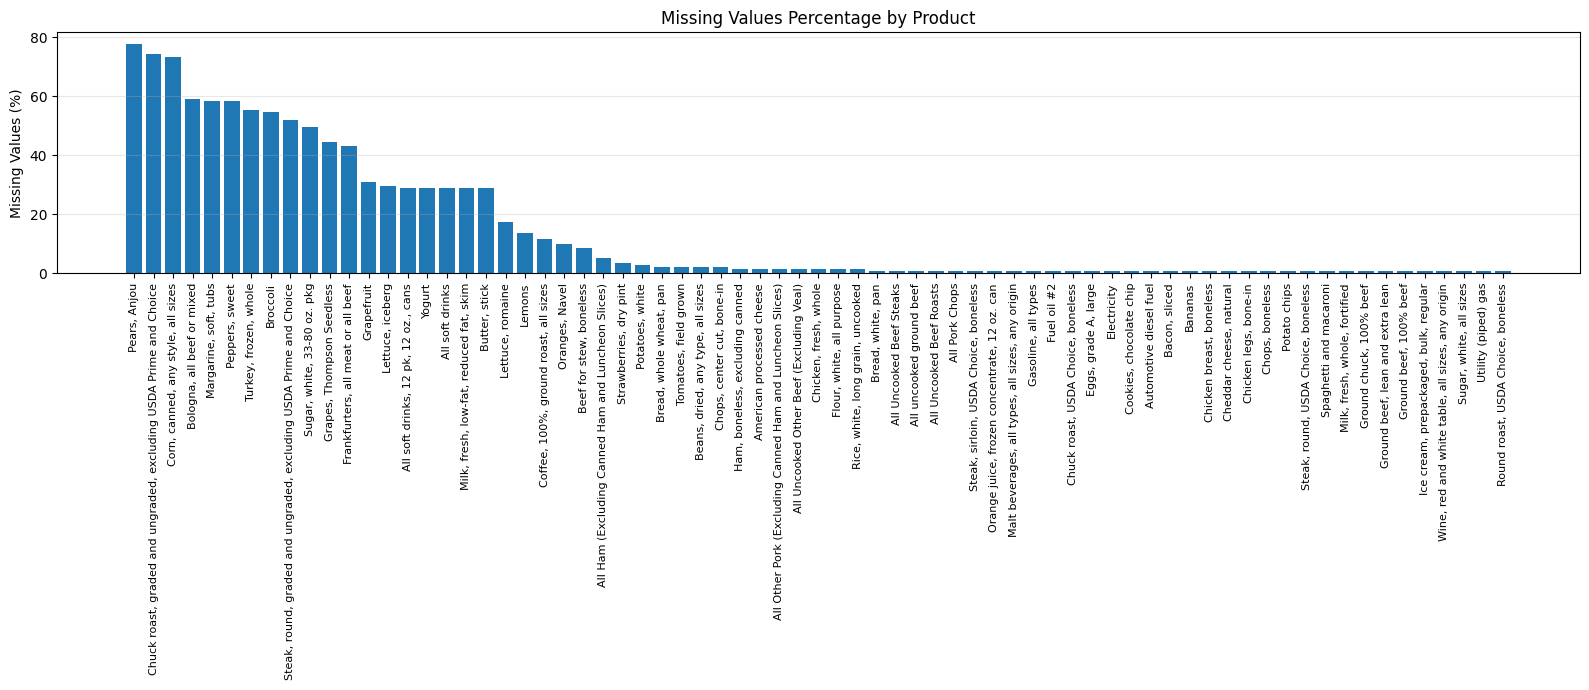

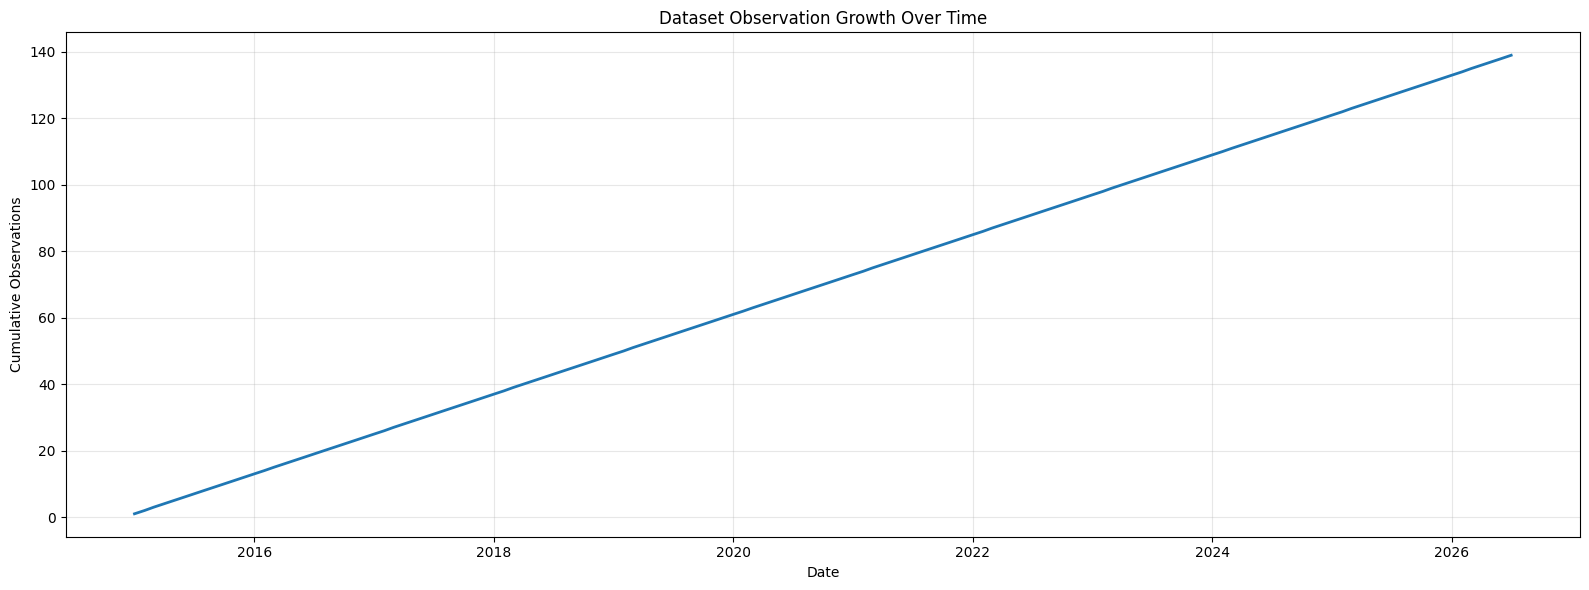

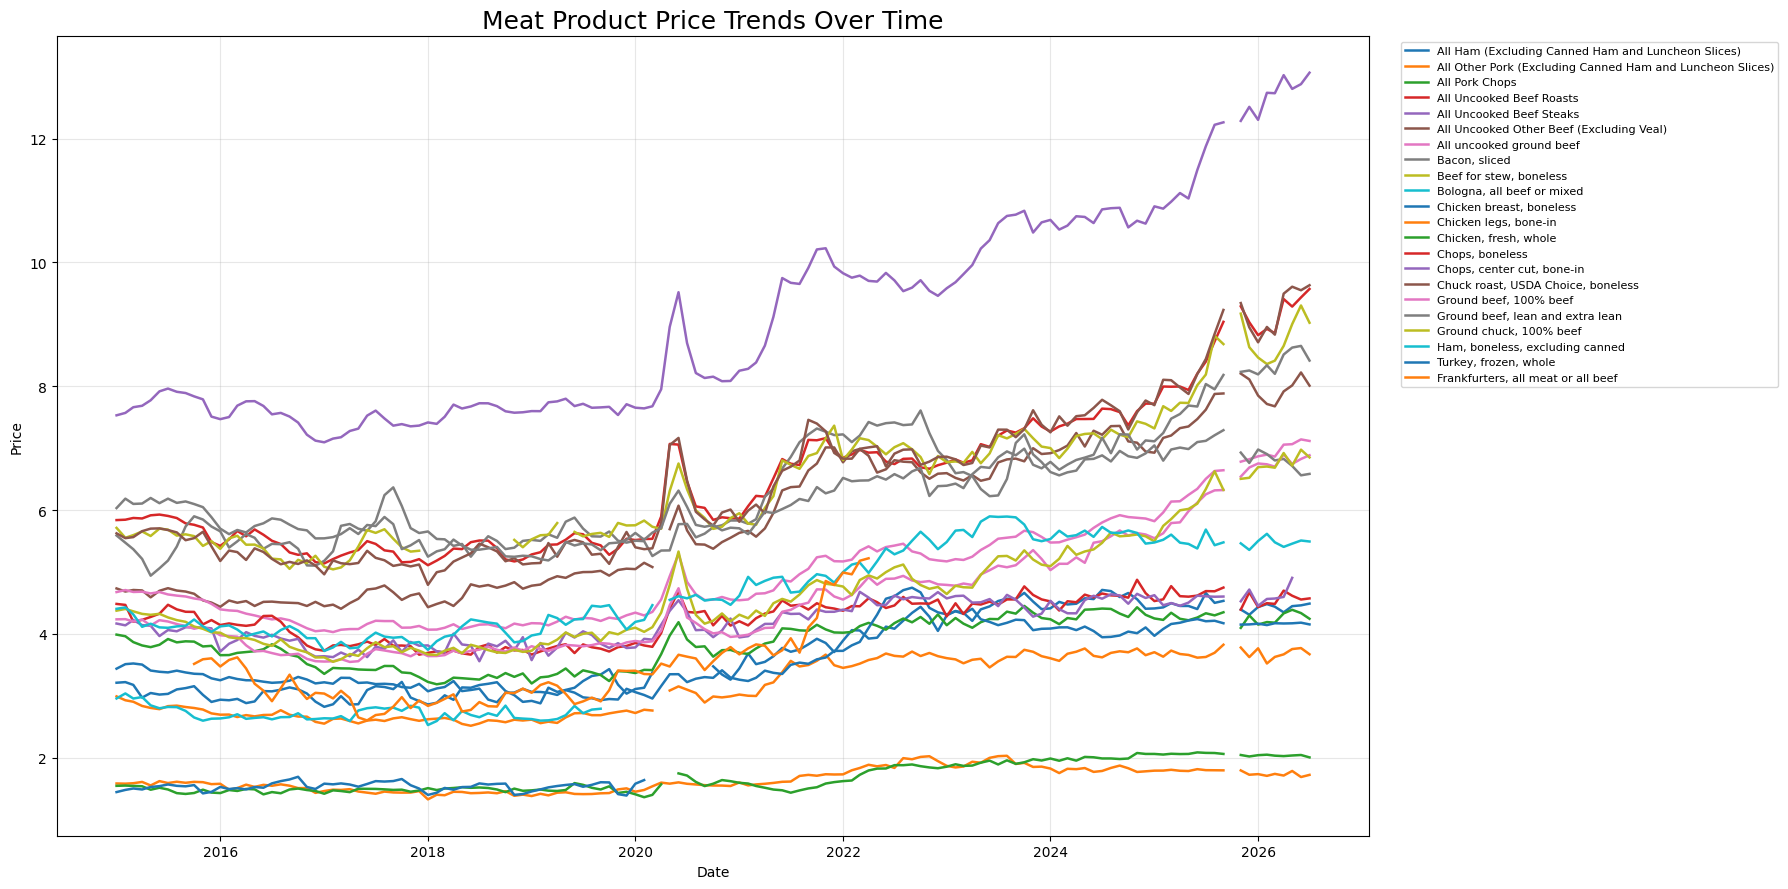

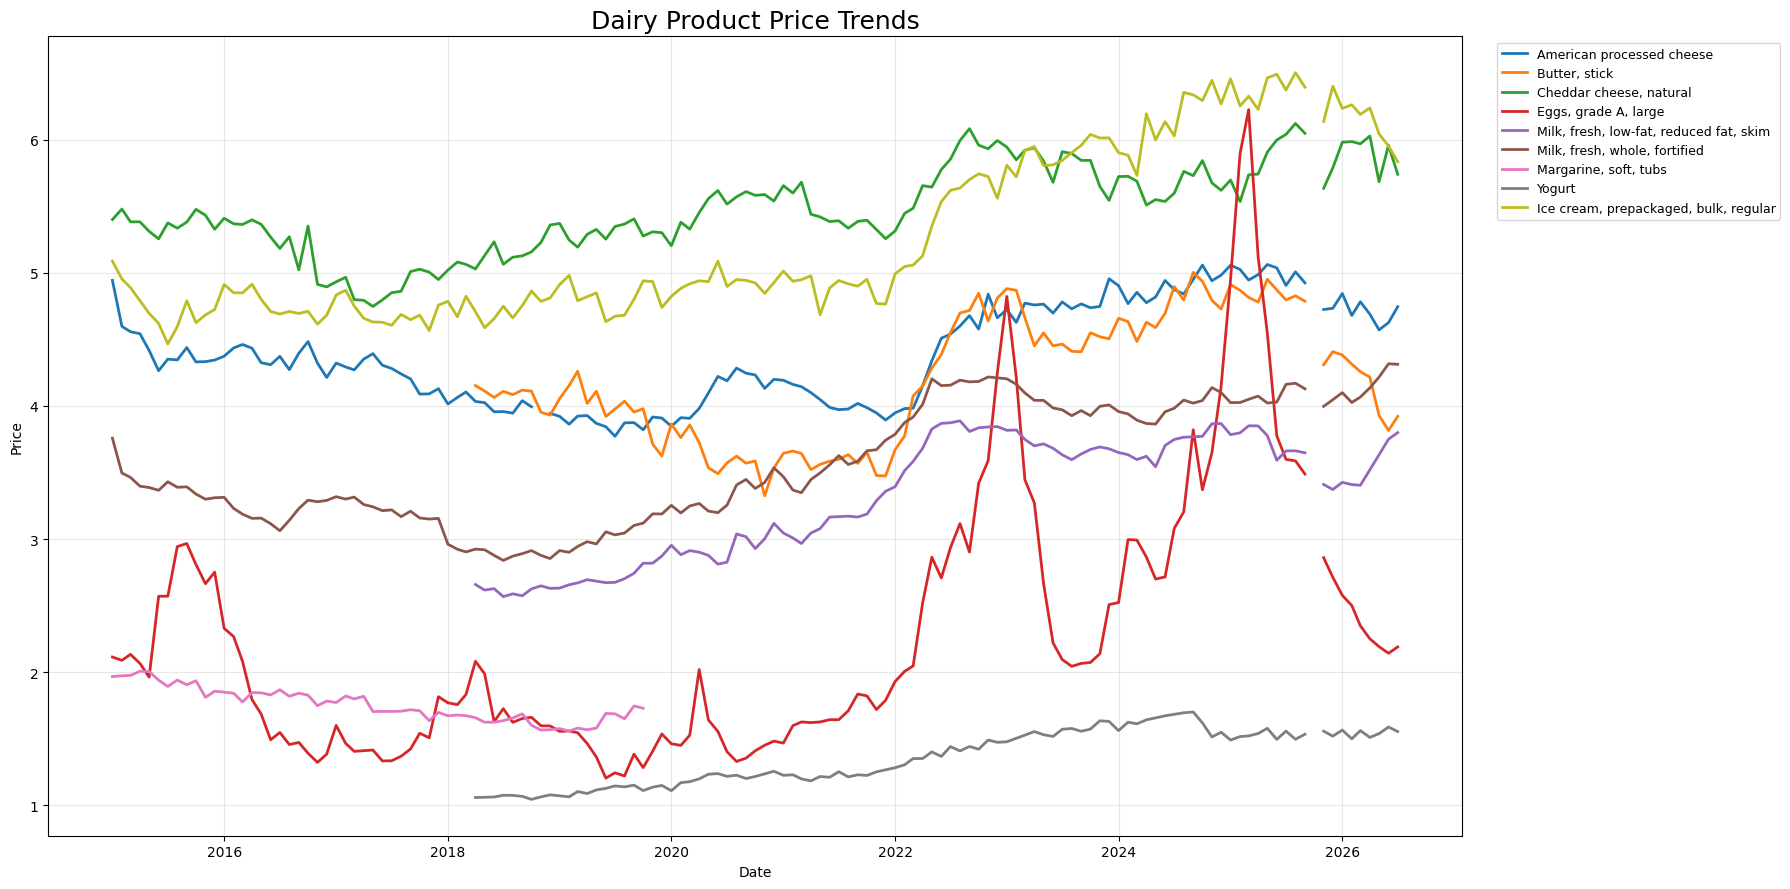

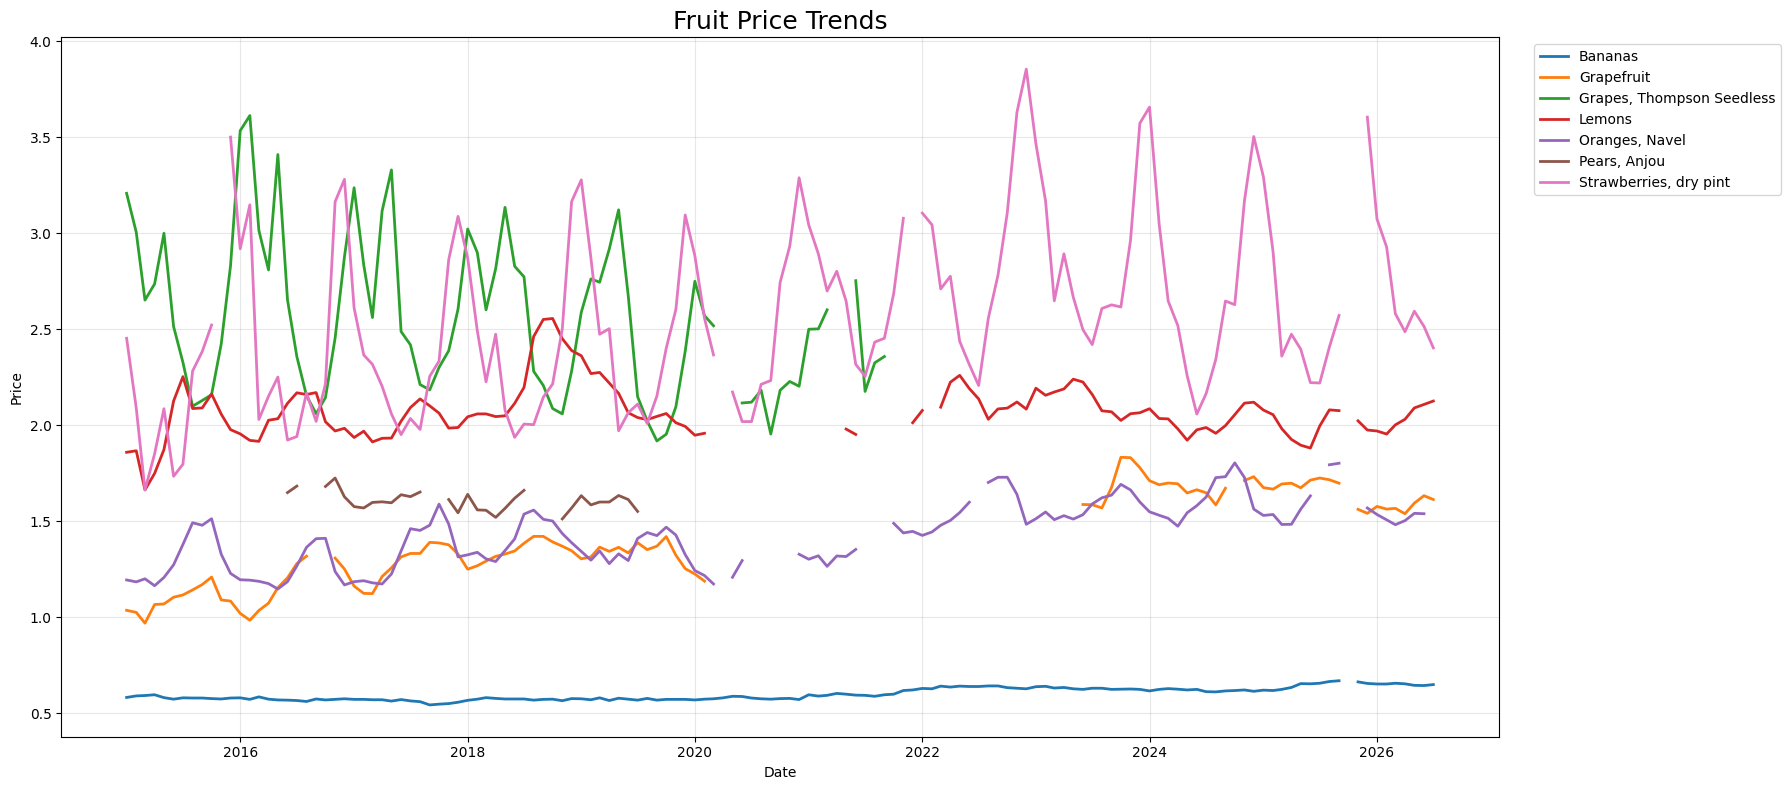

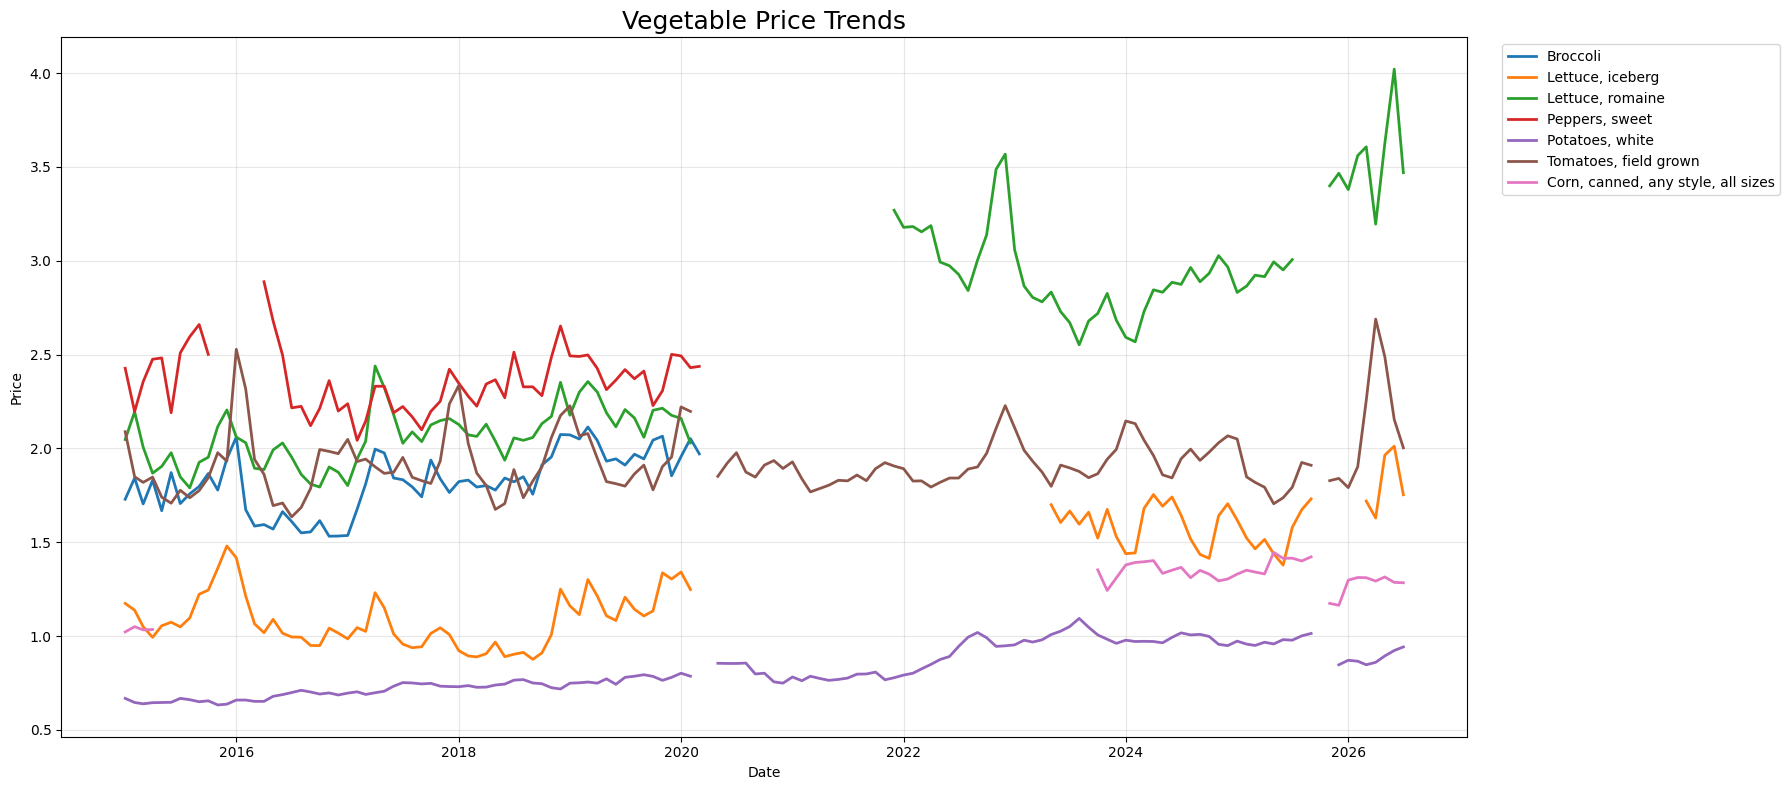

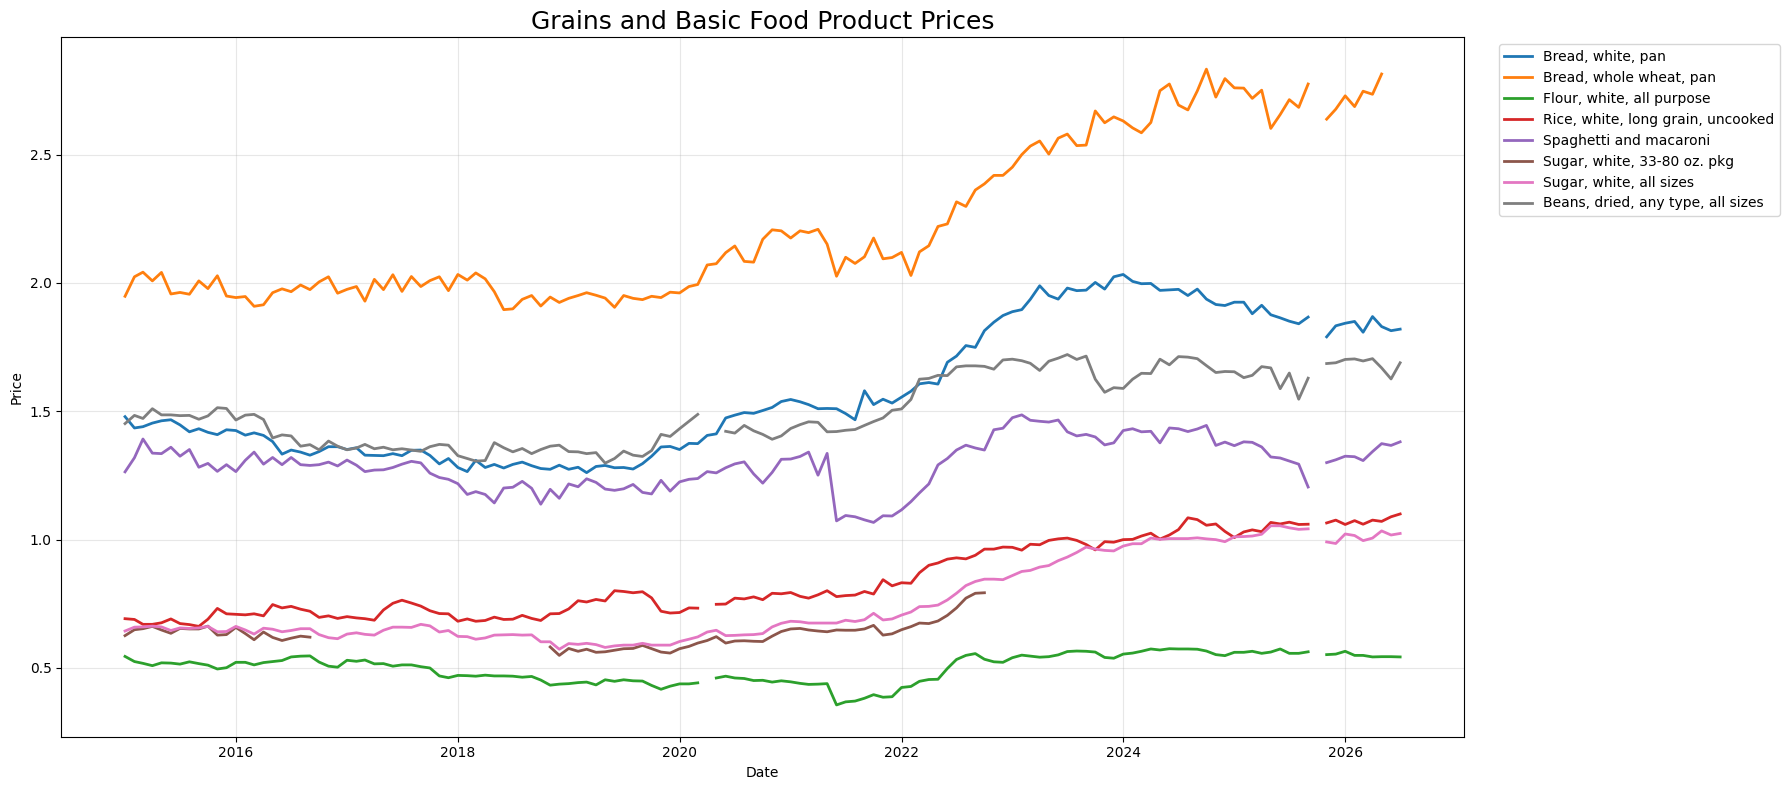

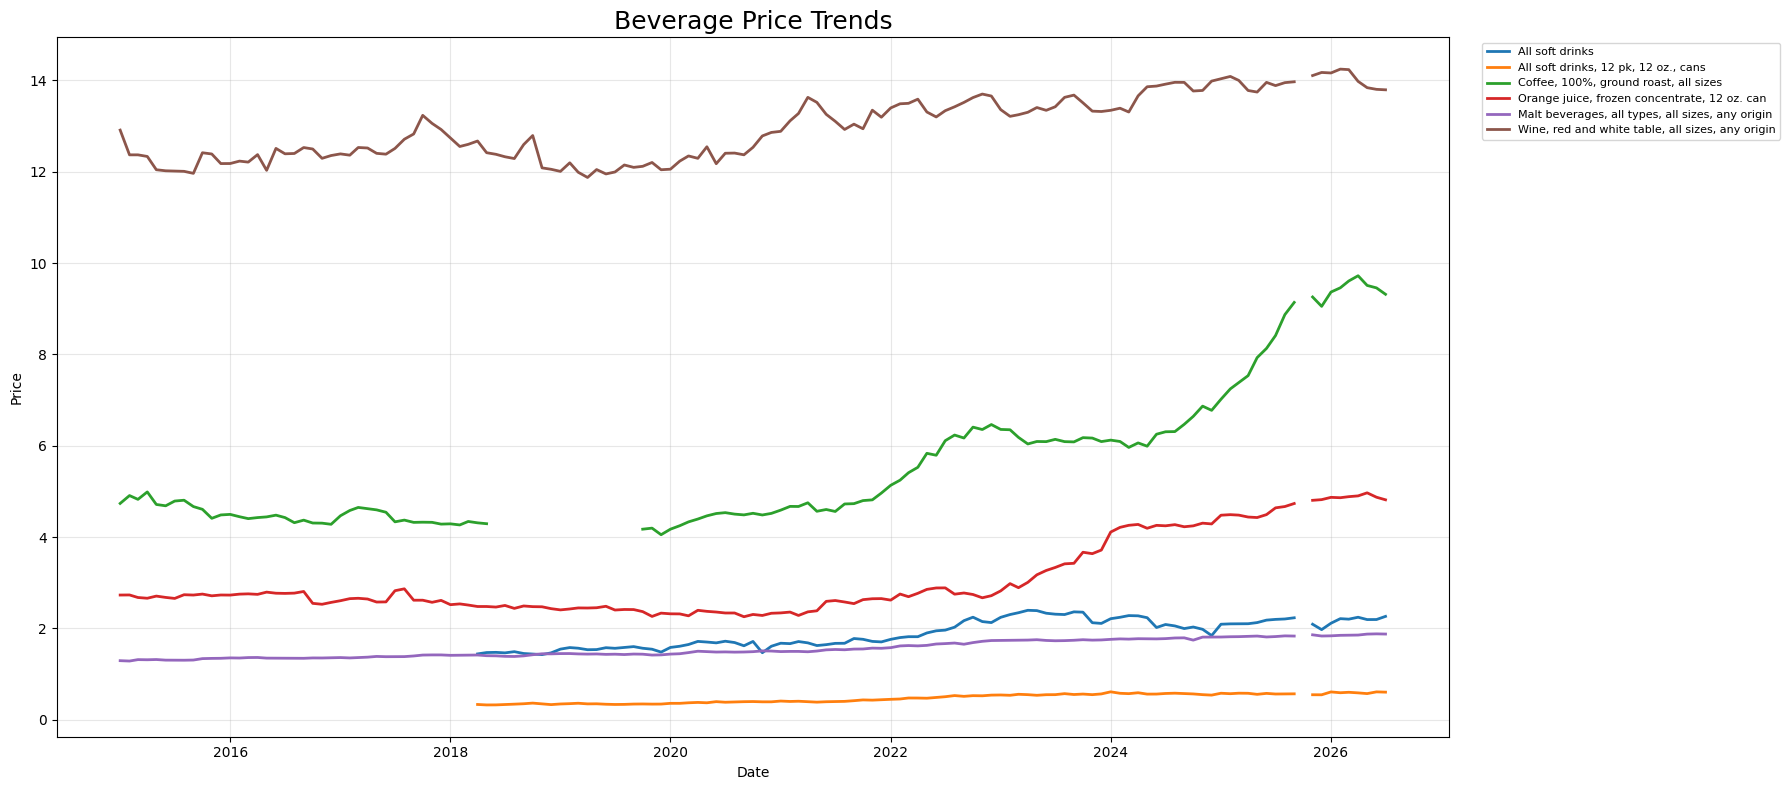

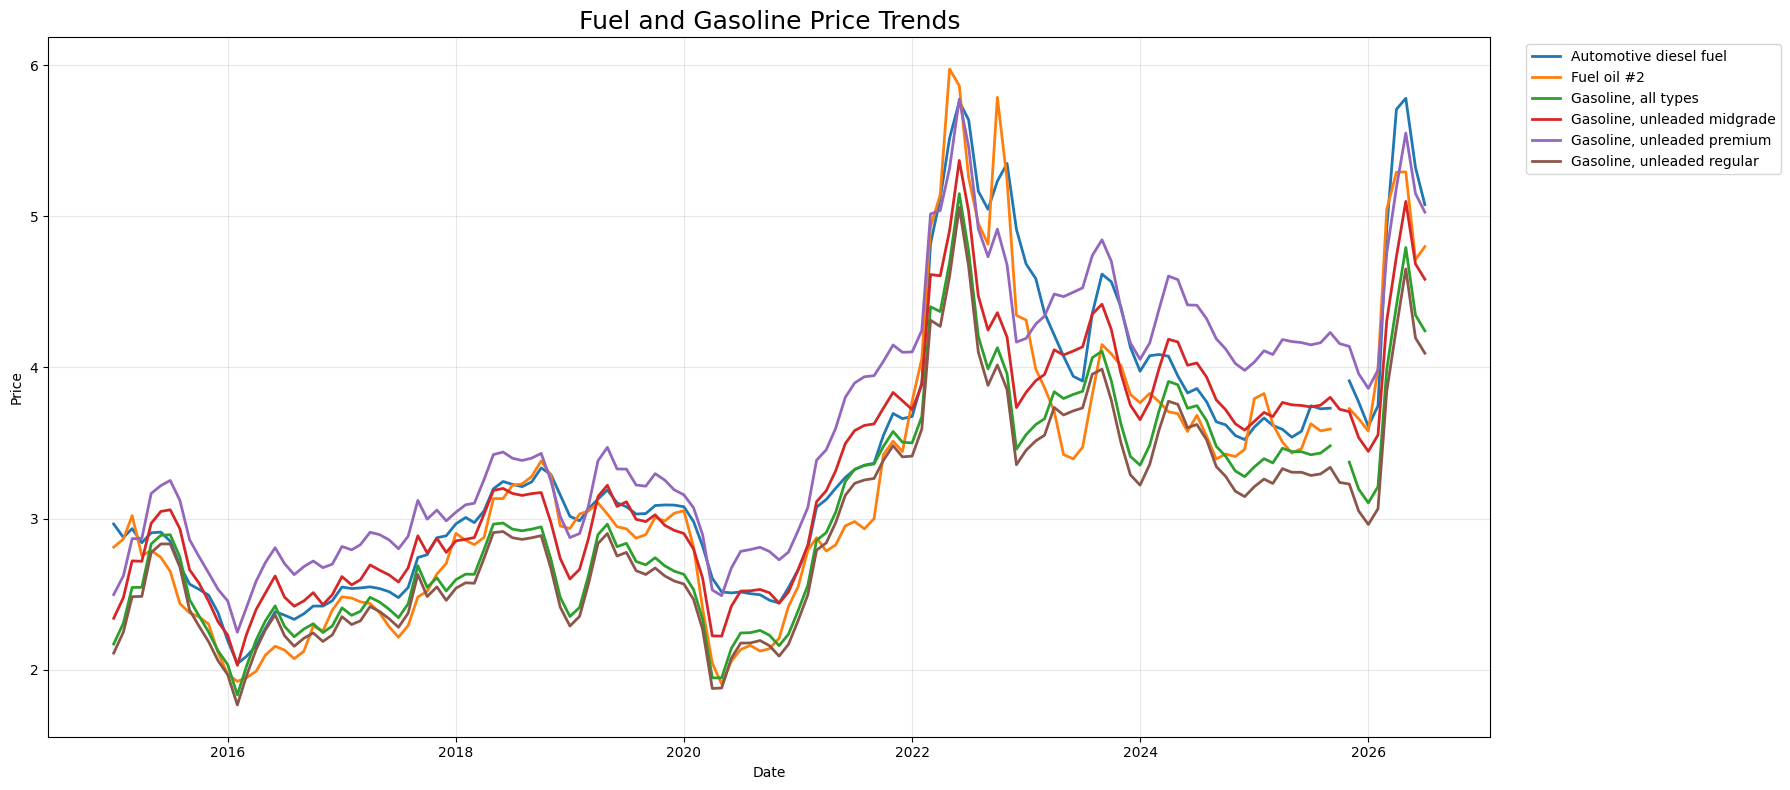

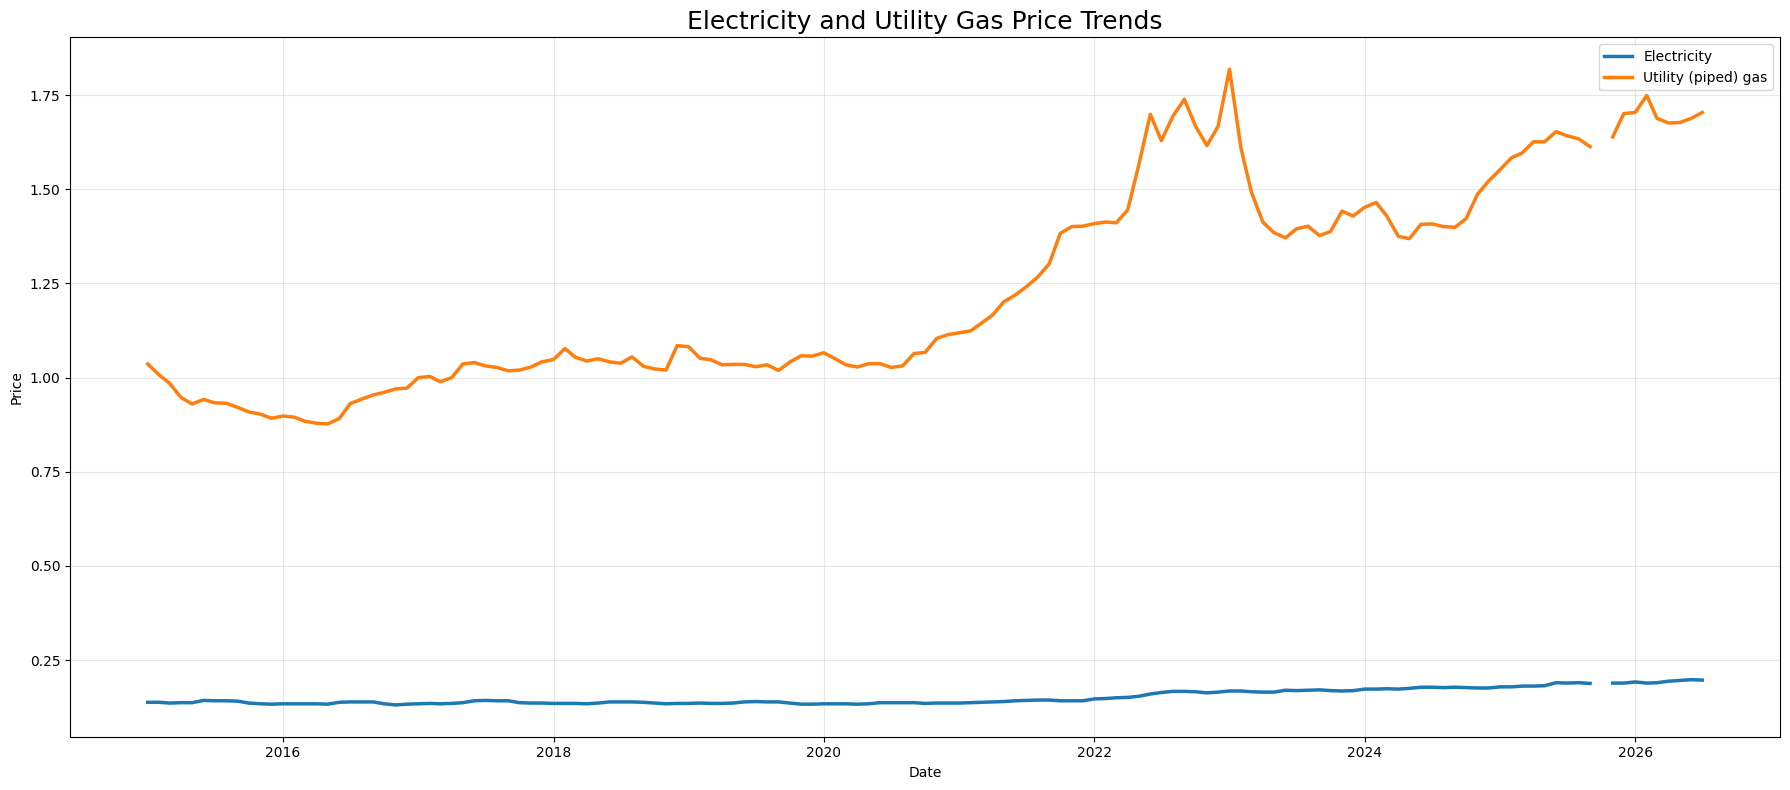

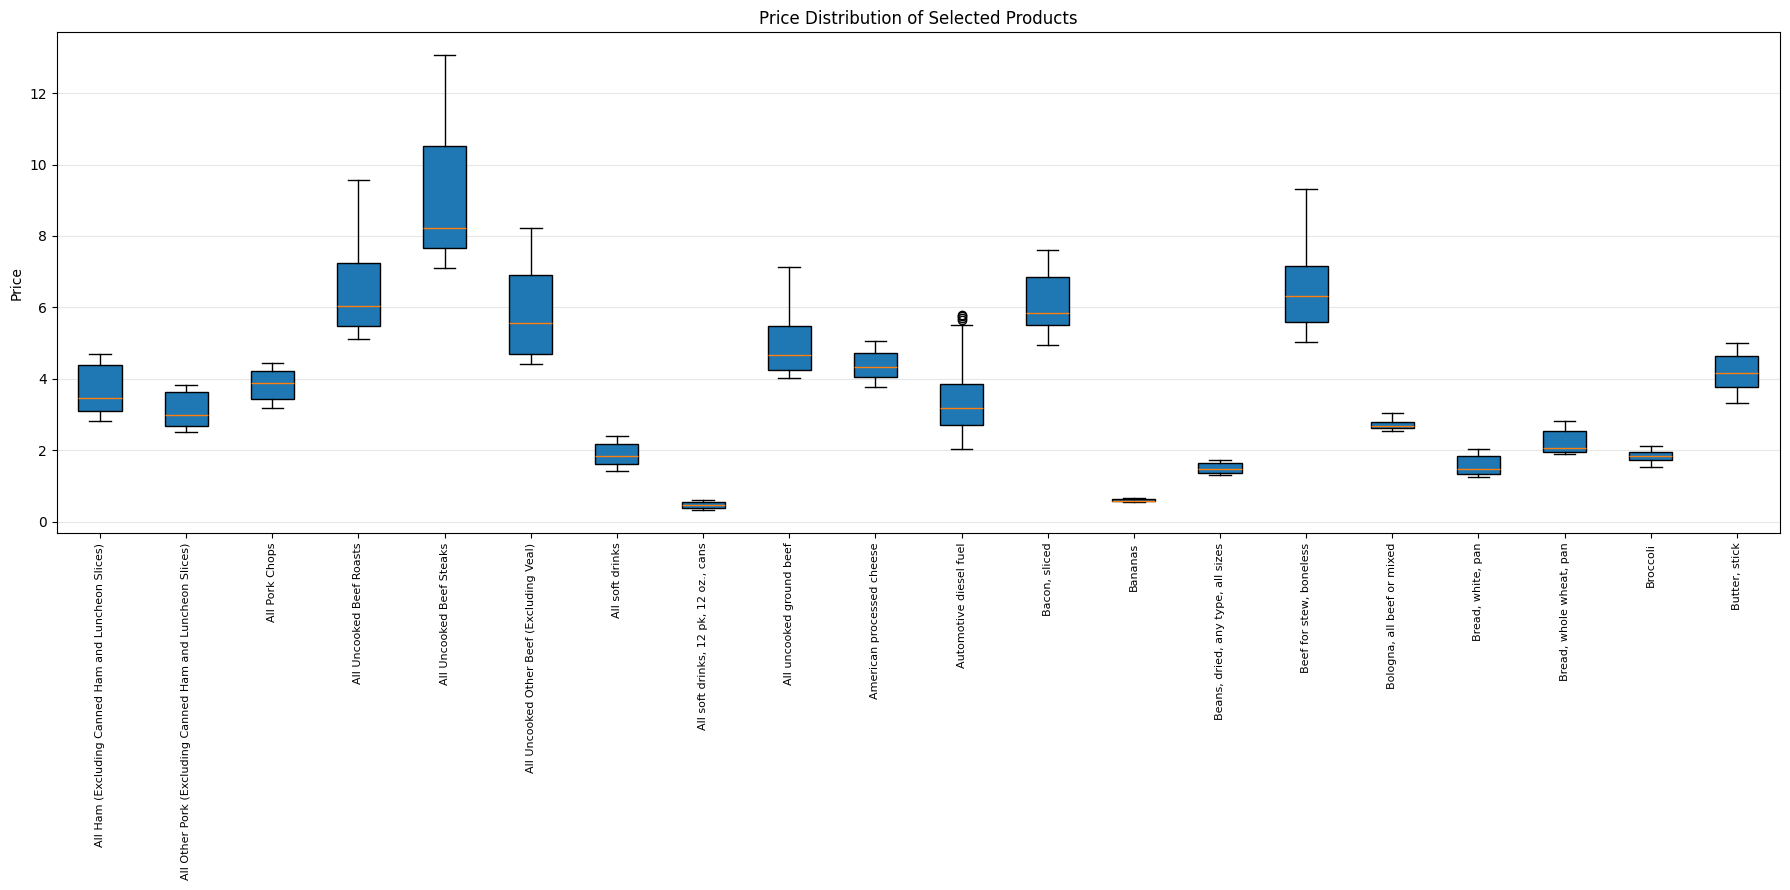

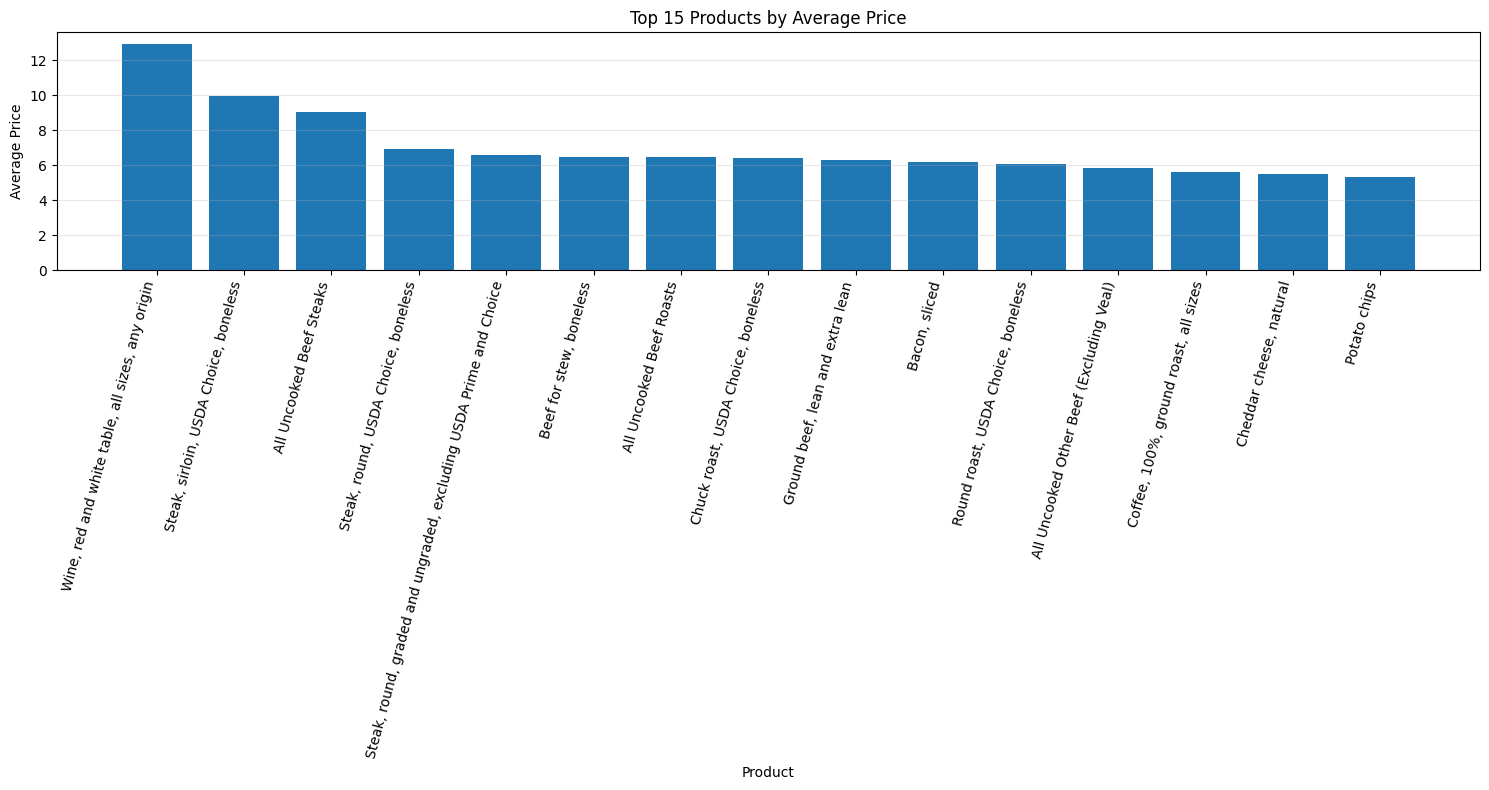

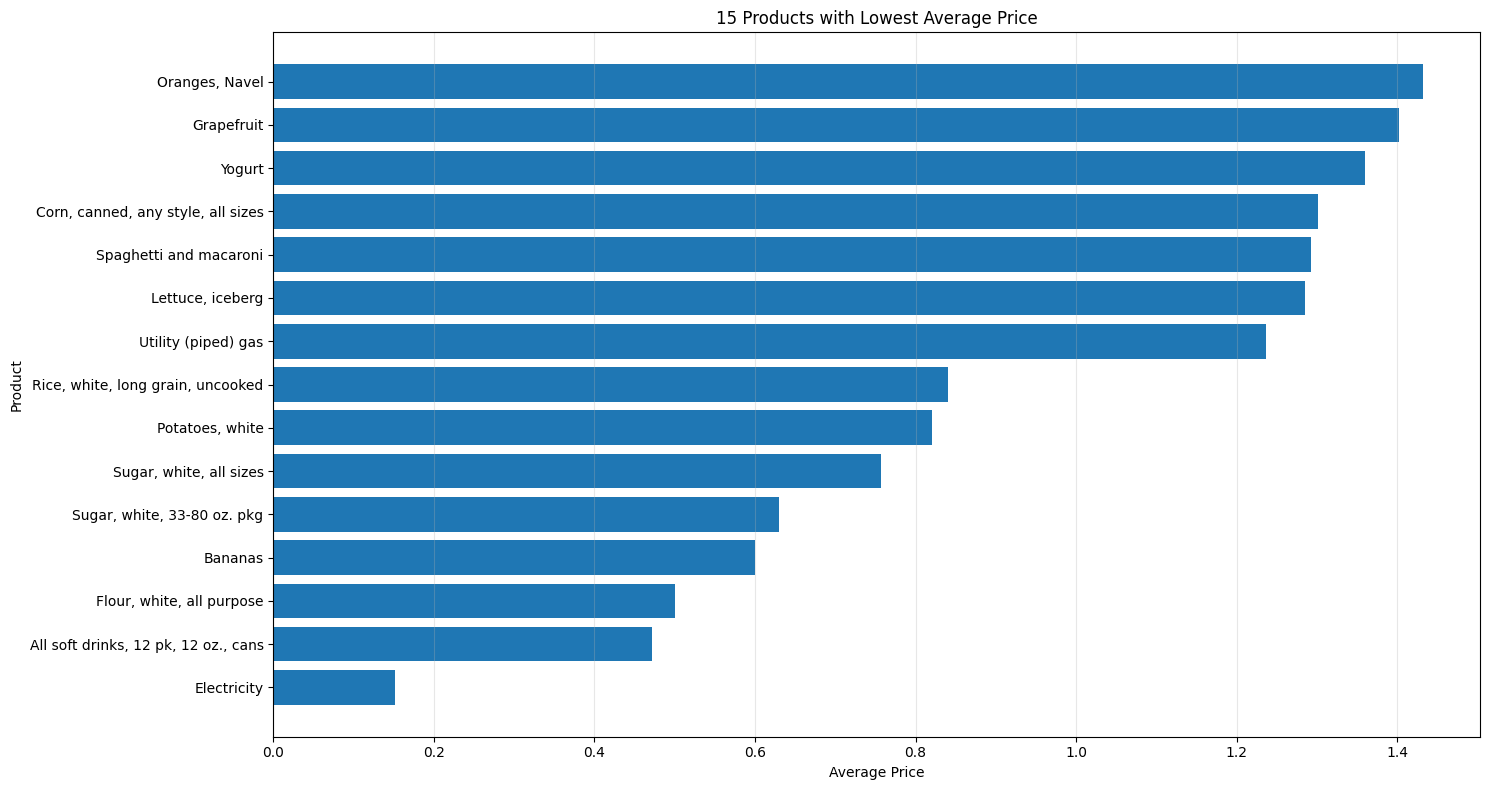

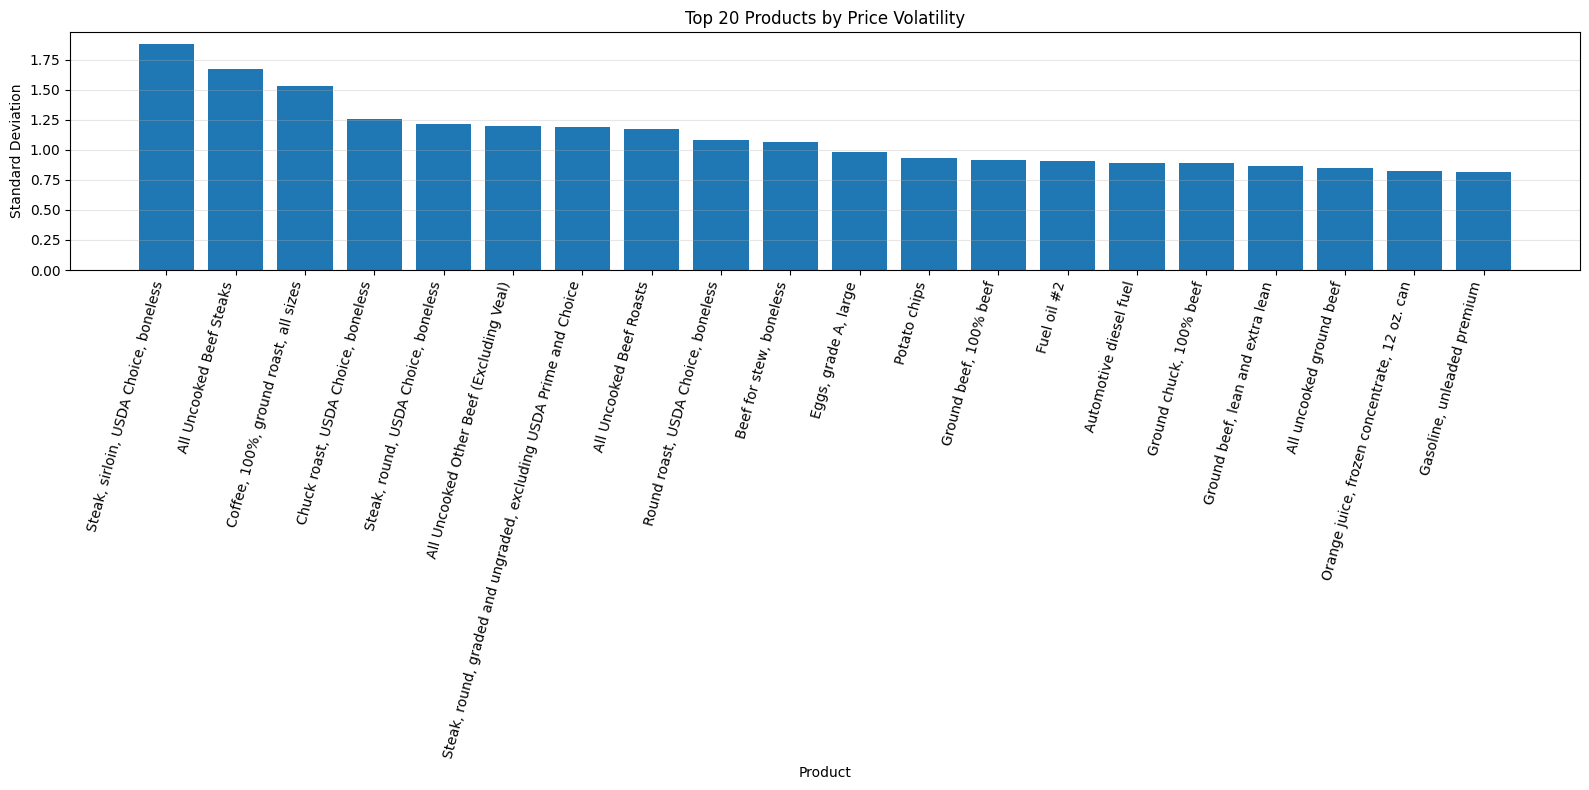

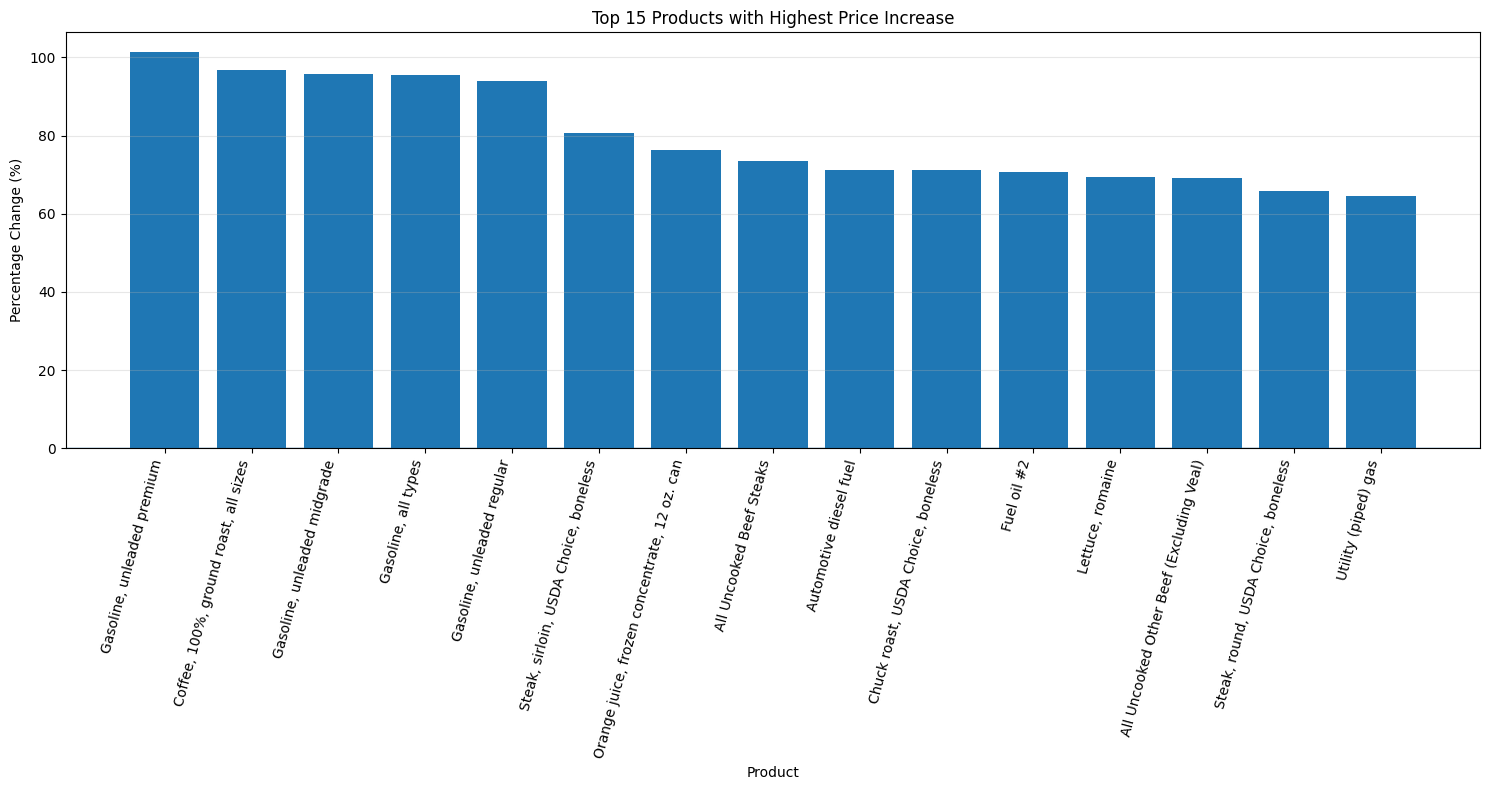

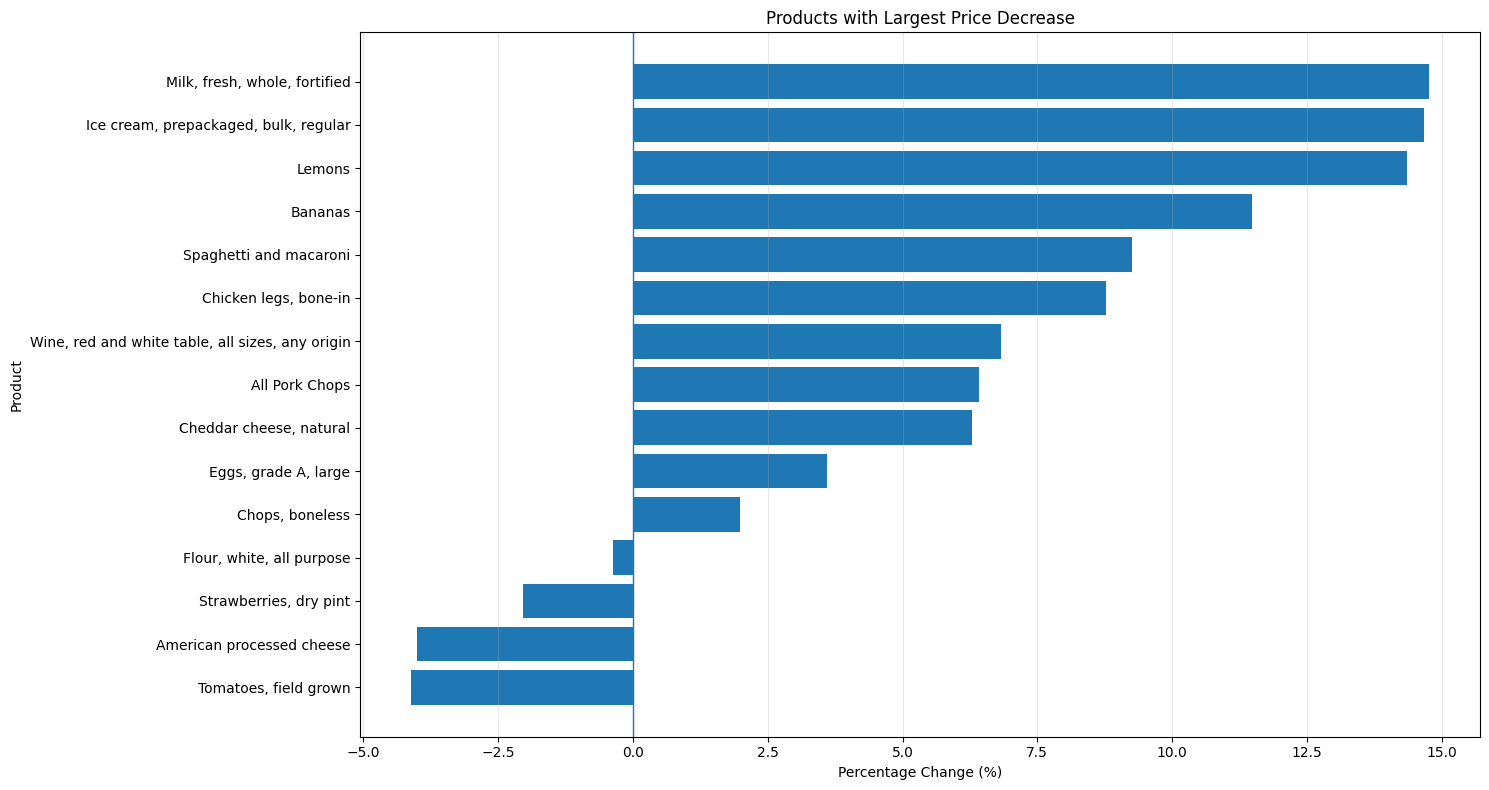

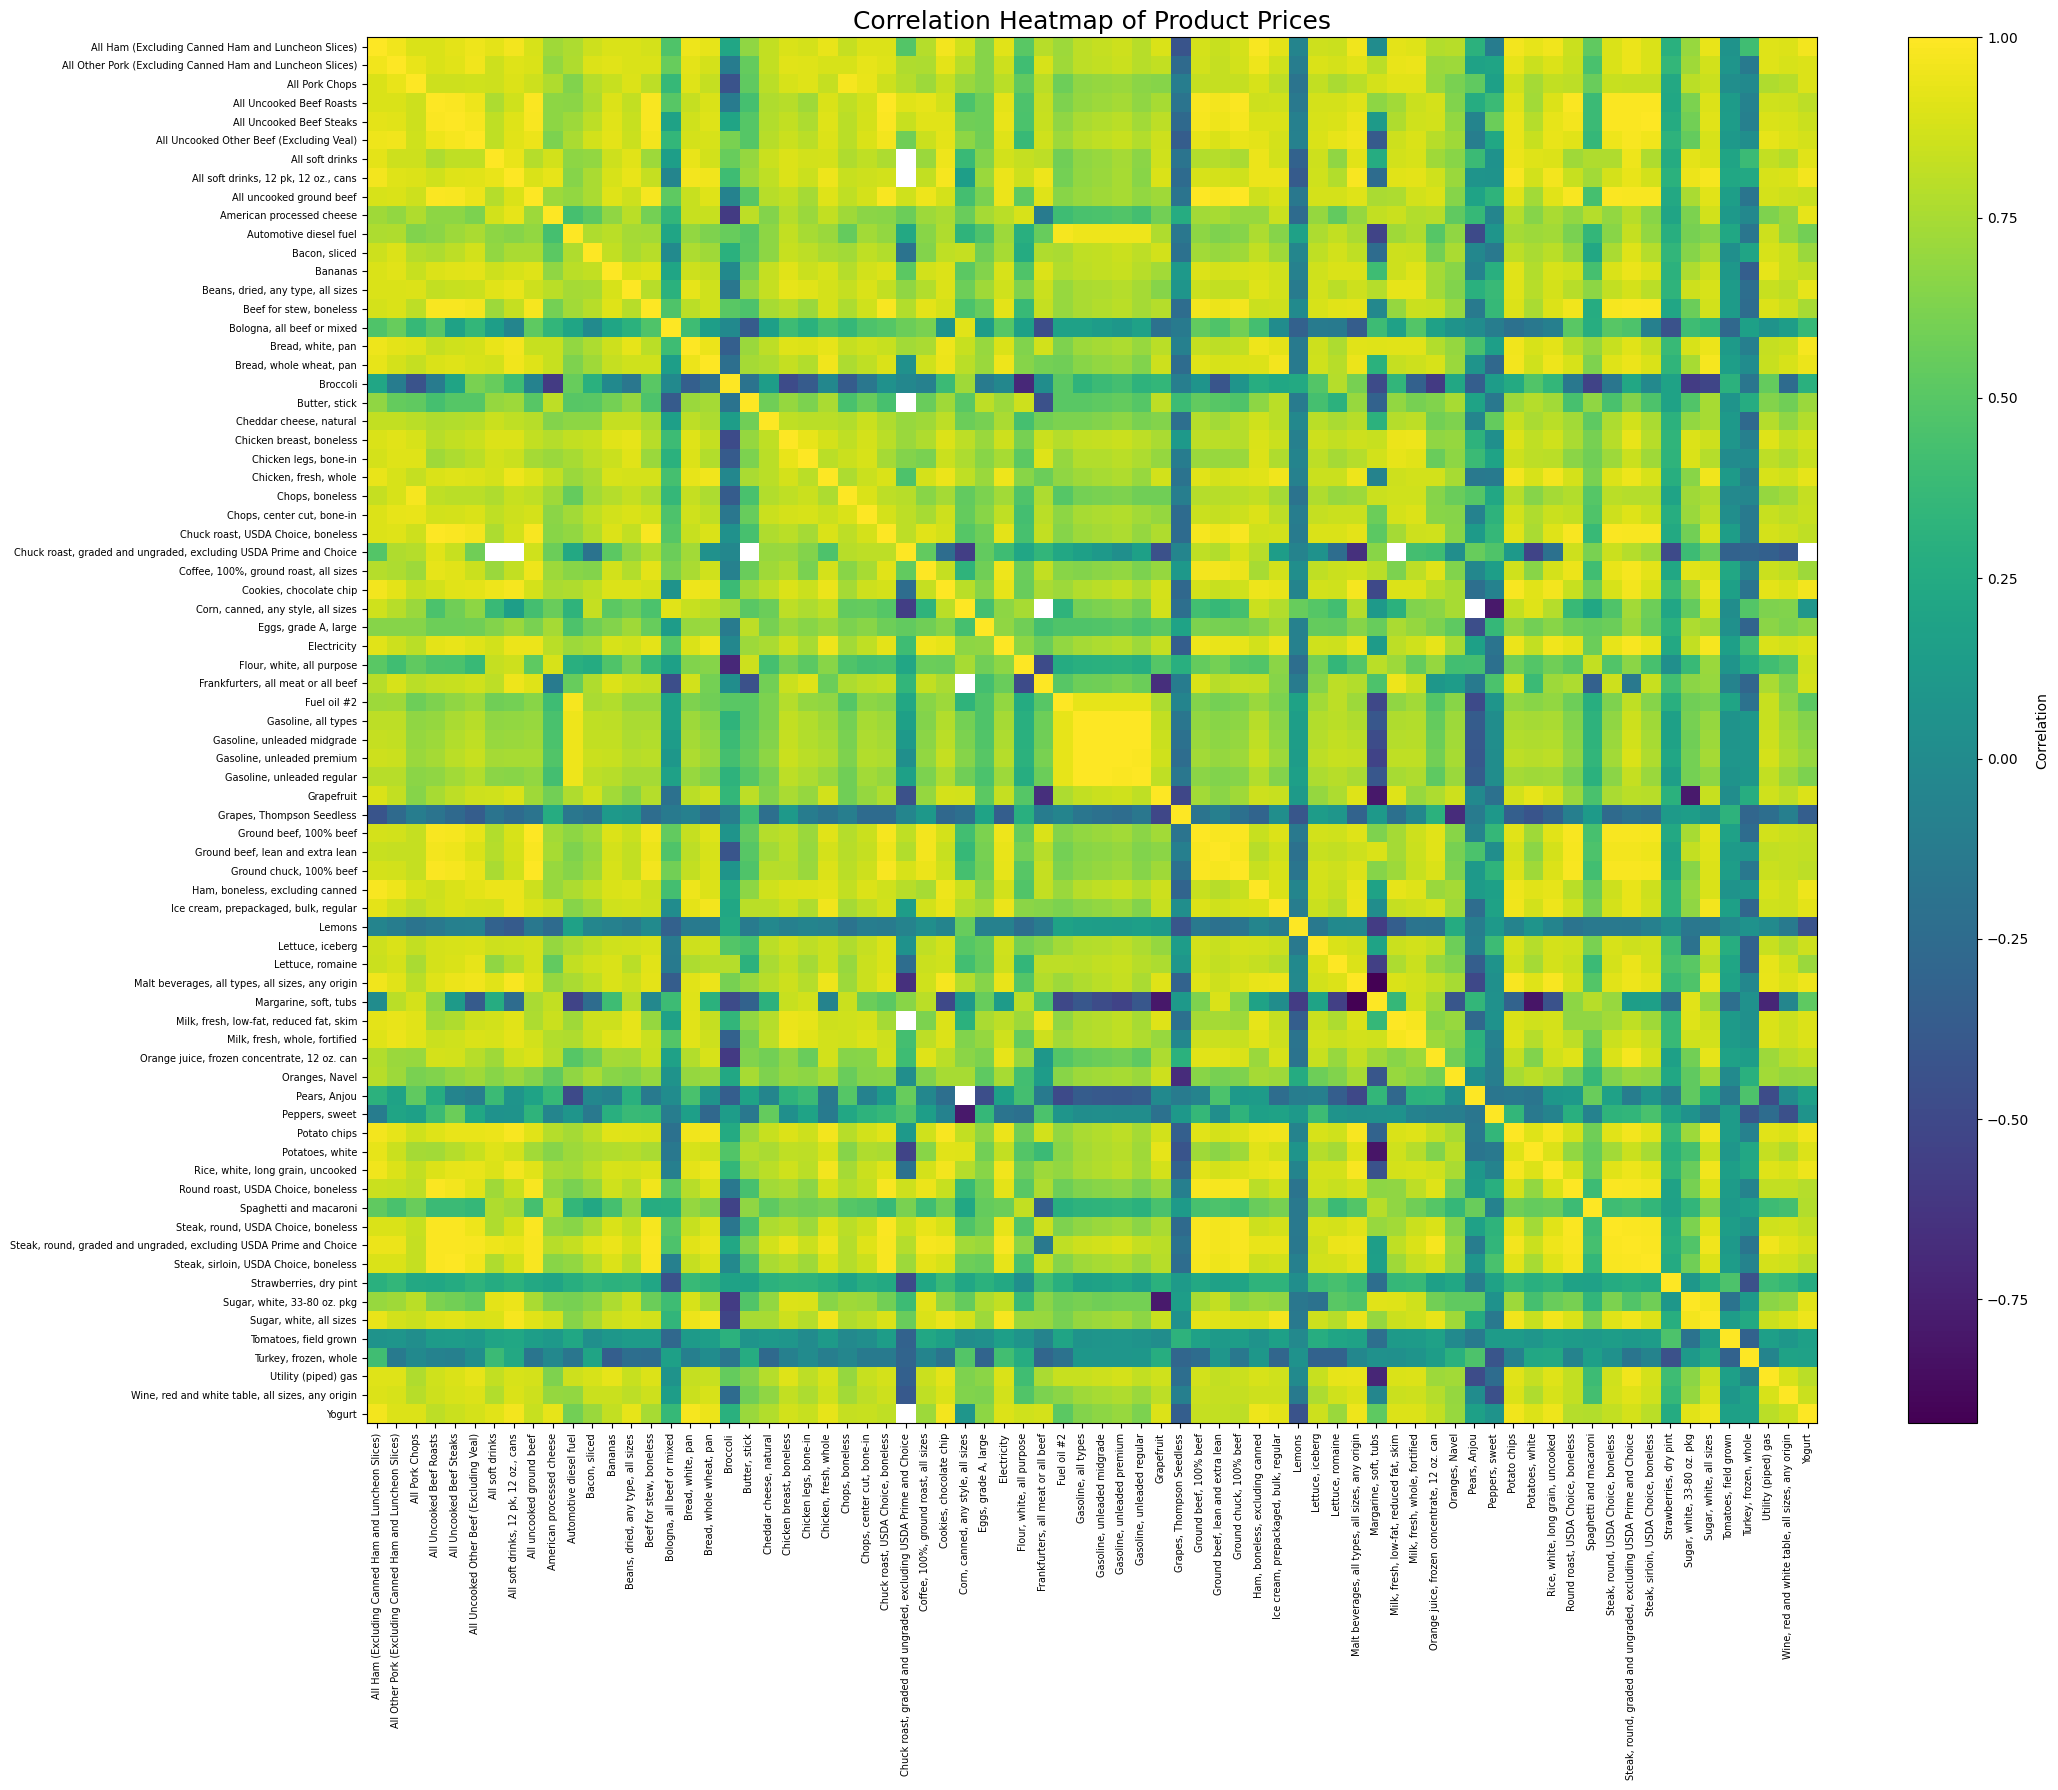

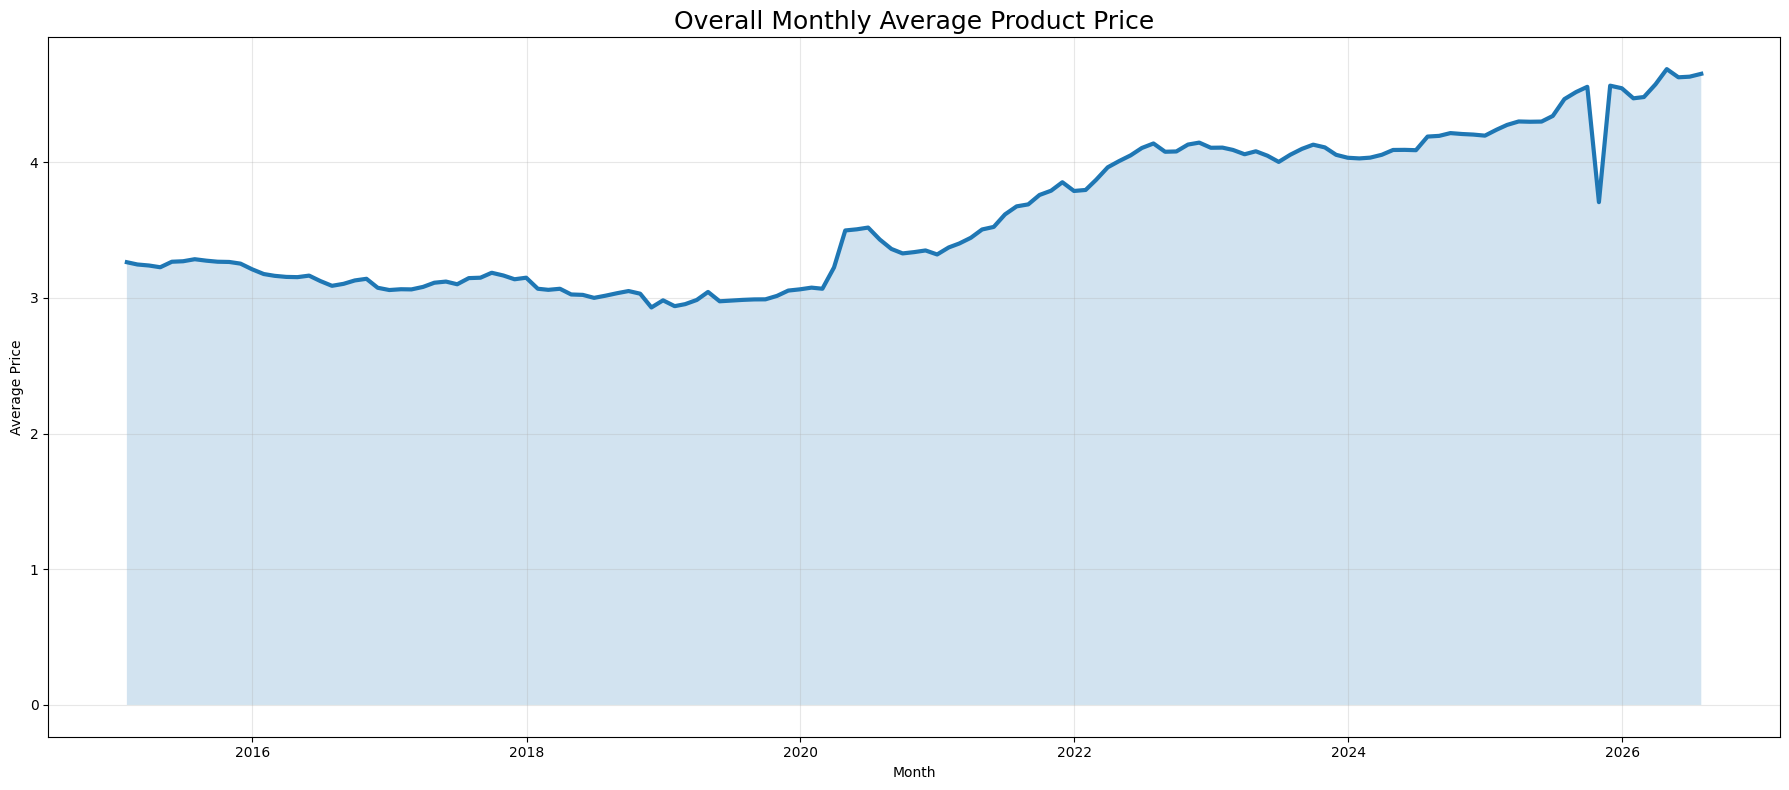

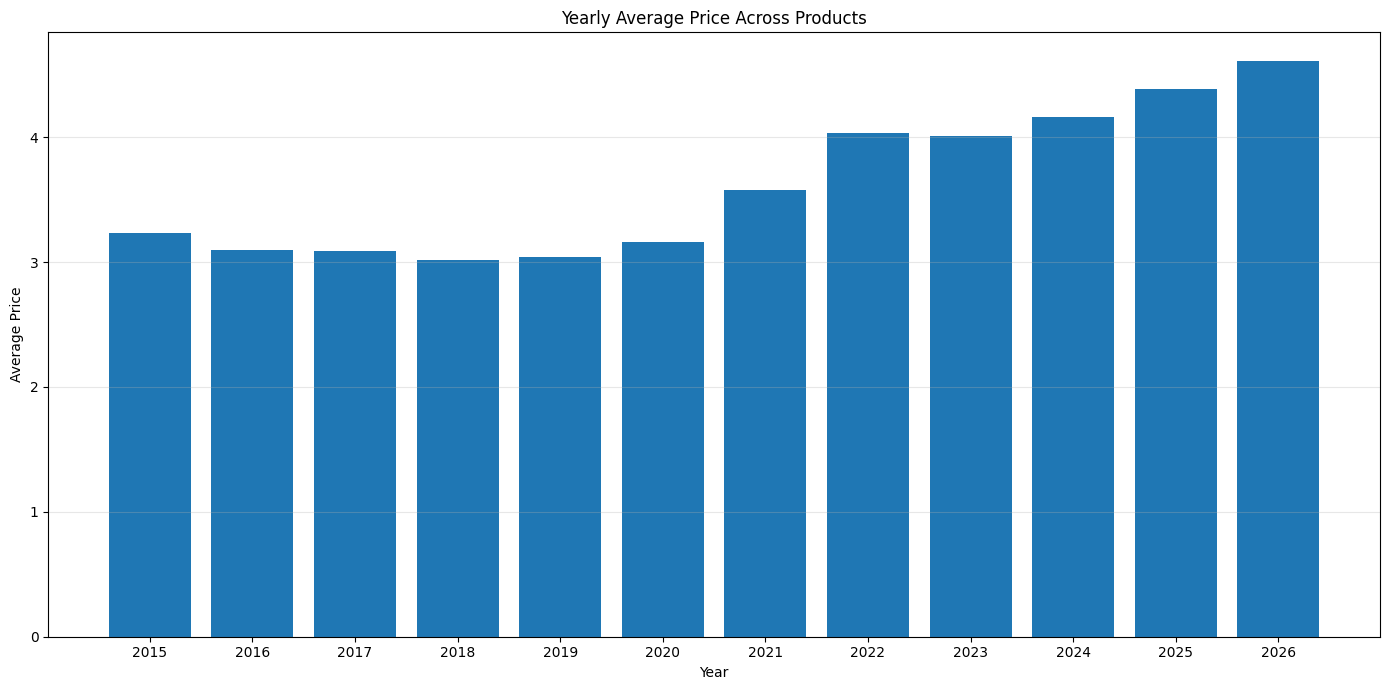

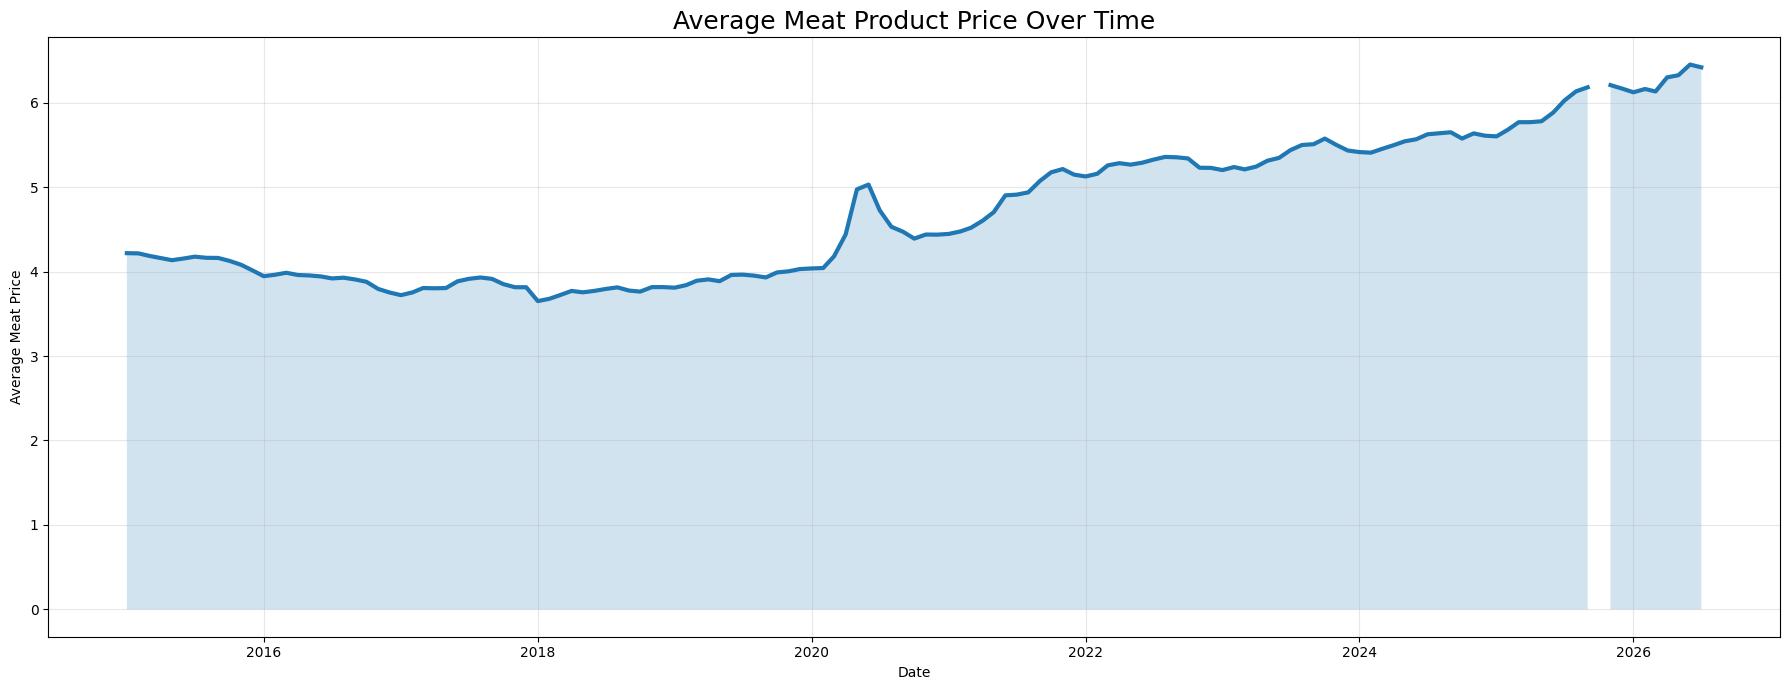

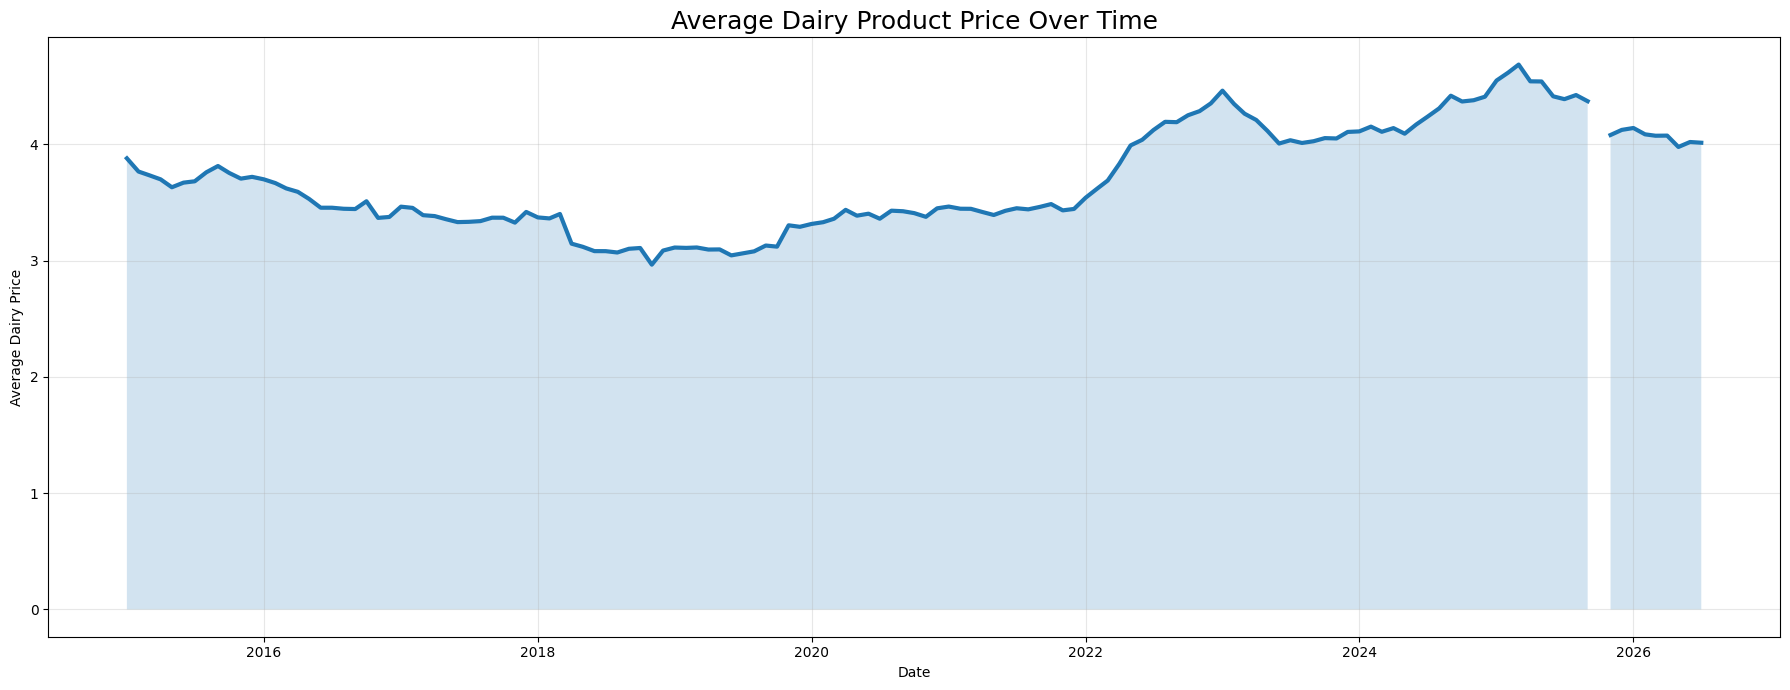

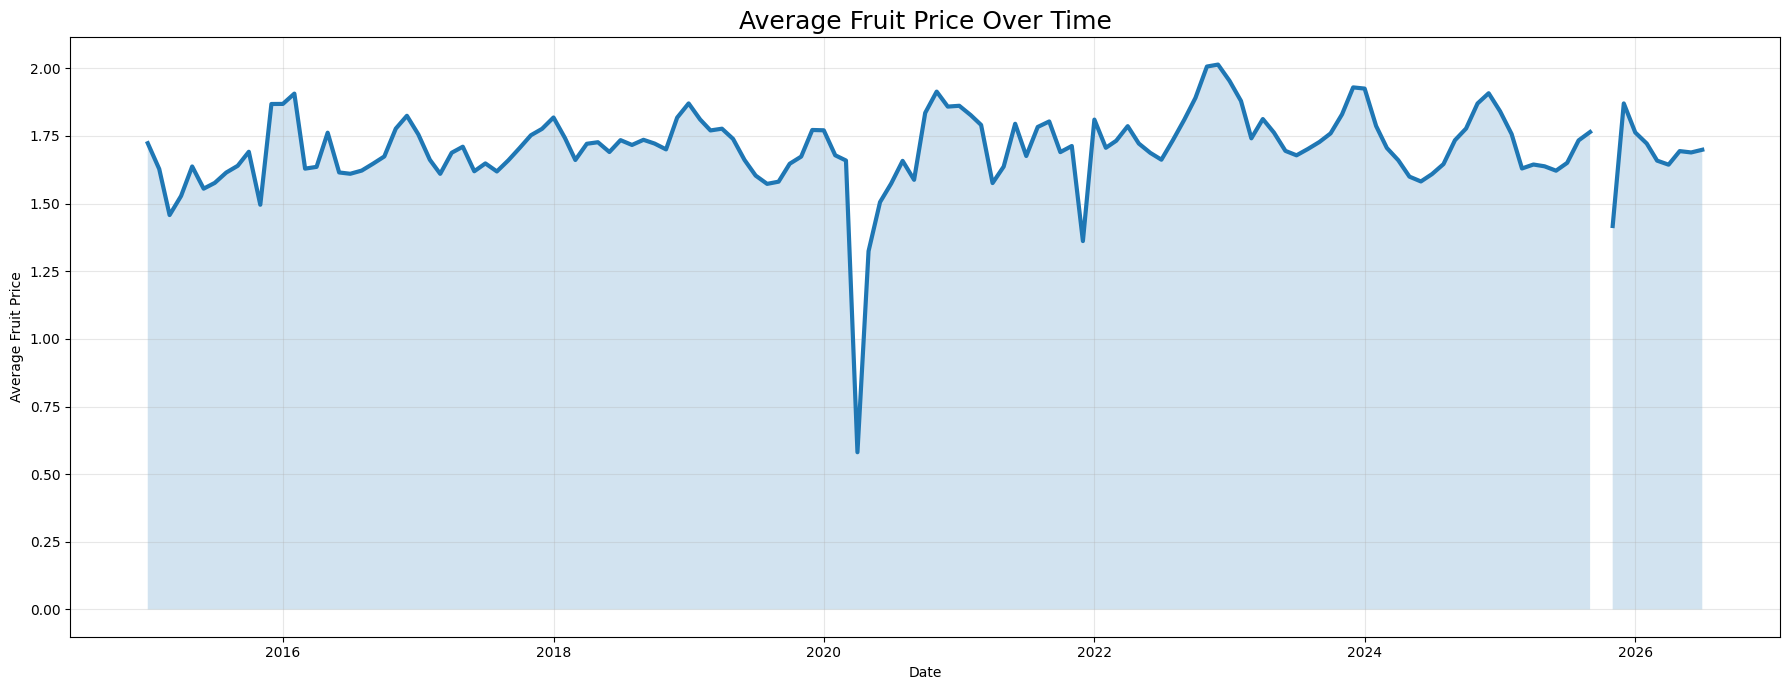

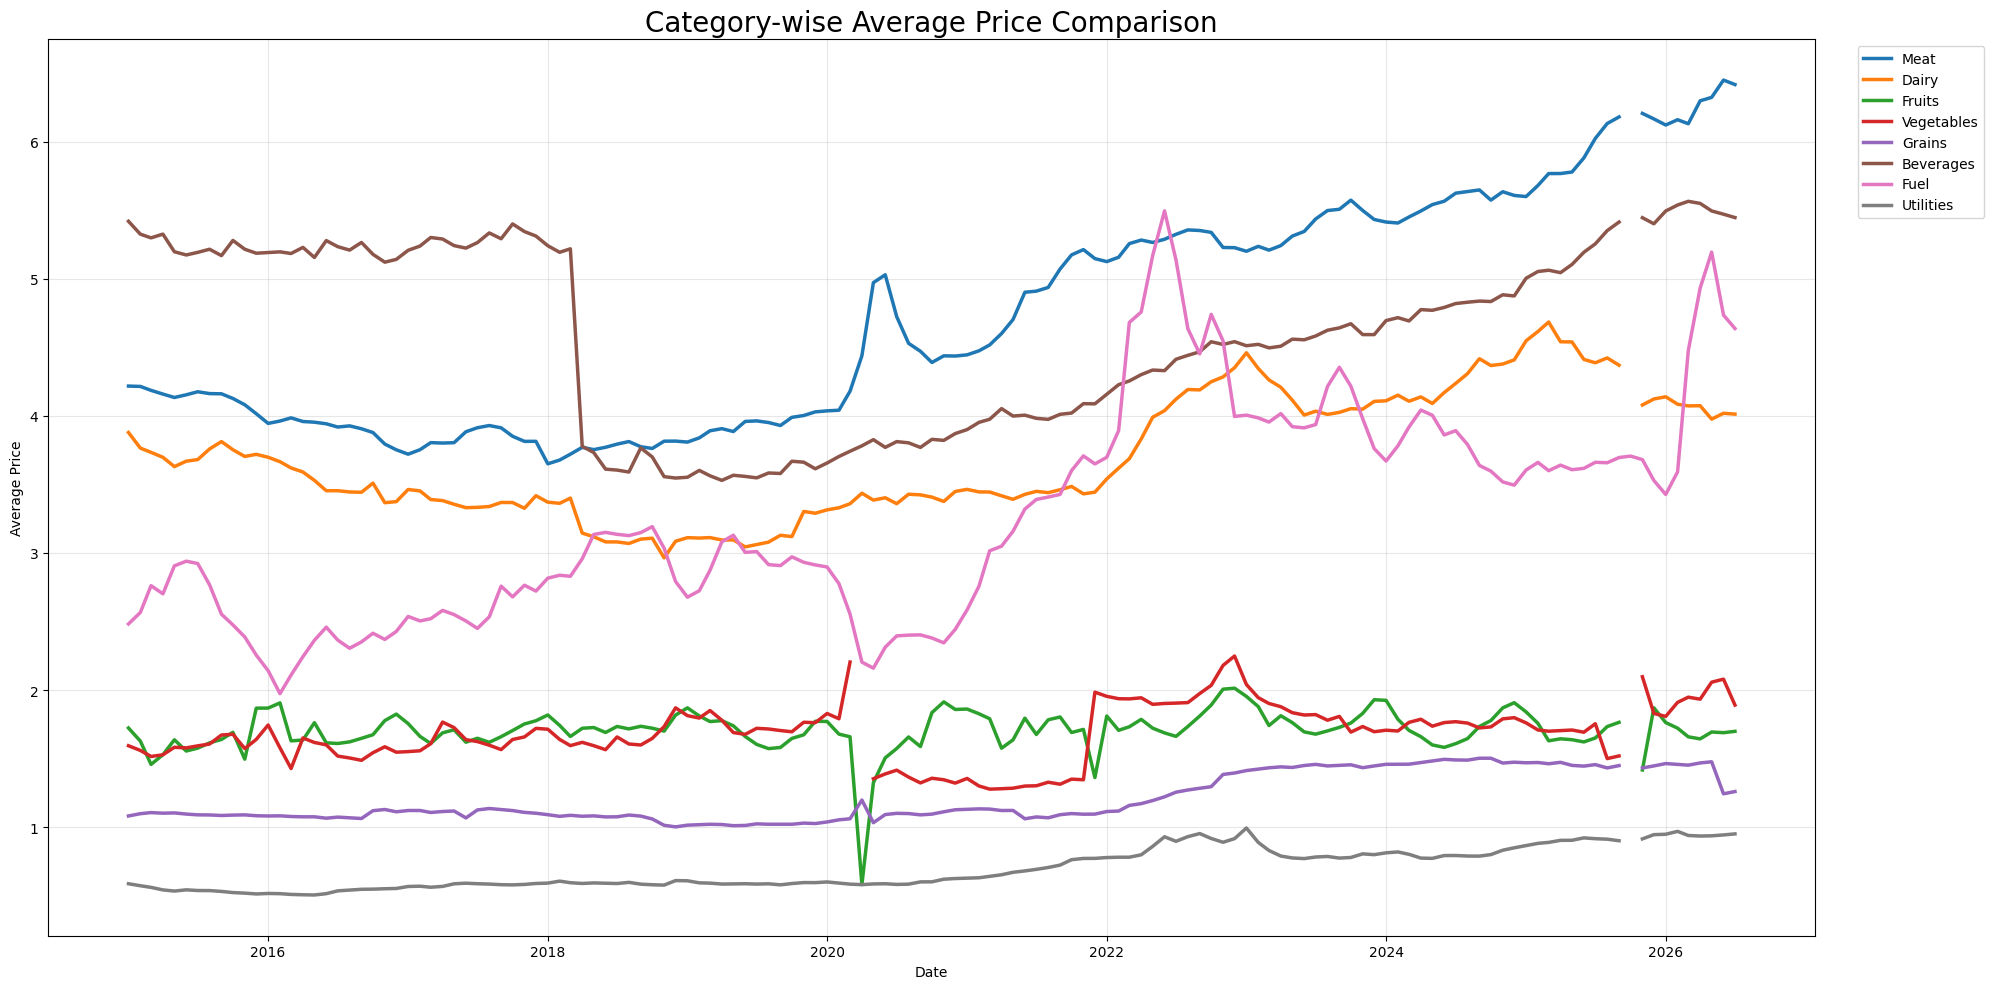

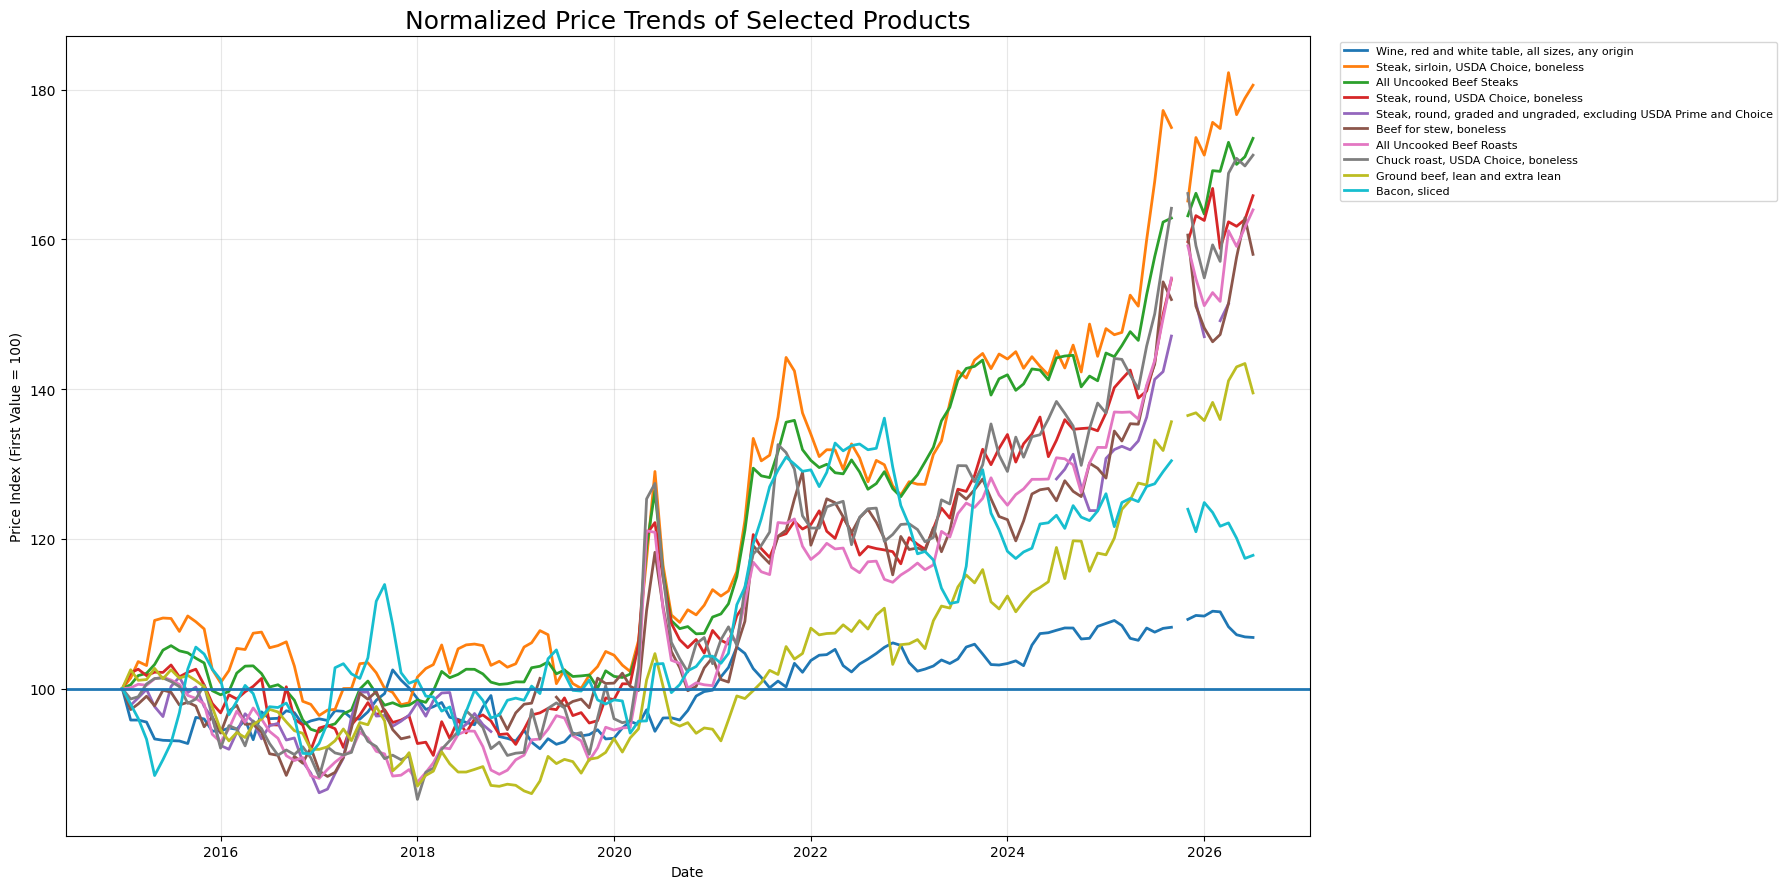



COMPLETE PRODUCT PRICE SUMMARY


,average,median,std_deviation,minimum,maximum,price_change_%
"Wine, red and white table, all sizes, any origin",12.95,12.90,0.69,11.88,14.25,6.83
"Steak, sirloin, USDA Choice, boneless",9.96,9.03,1.88,7.79,14.73,80.59
All Uncooked Beef Steaks,9.06,8.23,1.67,7.09,13.06,73.49
"Steak, round, USDA Choice, boneless",6.93,6.45,1.22,5.51,10.10,65.83
"Steak, round, graded and ungraded, excluding USDA Prime and Choice",6.60,6.02,1.19,5.30,9.34,NaN
...,...,...,...,...,...,...
"Sugar, white, 33-80 oz. pkg",0.63,0.63,0.05,0.55,0.79,NaN
Bananas,0.60,0.59,0.03,0.54,0.67,11.49
"Flour, white, all purpose",0.50,0.52,0.05,0.36,0.57,-0.37
"All soft drinks, 12 pk, 12 oz., cans",0.47,0.48,0.10,0.33,0.61,NaN



VISUALIZATION COMPLETED
Number of records       : 139
Number of products      : 74
Start date              : 2015-01-01
End date                : 2026-07-01

Product groups analyzed:
Meat                    : 22
Dairy                   : 9
Fruits                  : 7
Vegetables              : 7
Grains                  : 8
Beverages               : 6
Fuel                    : 6
Utilities               : 2

All visualizations generated successfully.


In [13]:
# df = pd.read_csv("your_file.csv")

data = df_wide.copy()

# ------------------------------------------------------------
# 2. BASIC DATA PREPARATION
# ------------------------------------------------------------

# Convert date column to datetime
data["date"] = pd.to_datetime(data["date"], errors="coerce")

# Sort by date
data = data.sort_values("date").reset_index(drop=True)

# Remove rows where date is missing
data = data.dropna(subset=["date"])

# Convert all non-date columns to numeric
numeric_columns = data.columns.drop("date")

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Display dataset information
print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)
print(data.shape)

print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(data.dtypes)

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(data.isnull().sum().sort_values(ascending=False).head(20))

print("\n" + "=" * 80)
print("DATE RANGE")
print("=" * 80)
print("Start Date:", data["date"].min())
print("End Date  :", data["date"].max())


# ============================================================
# 3. IDENTIFY PRODUCT GROUPS
# ============================================================

meat_cols = [
    "All Ham (Excluding Canned Ham and Luncheon Slices)",
    "All Other Pork (Excluding Canned Ham and Luncheon Slices)",
    "All Pork Chops",
    "All Uncooked Beef Roasts",
    "All Uncooked Beef Steaks",
    "All Uncooked Other Beef (Excluding Veal)",
    "All uncooked ground beef",
    "Bacon, sliced",
    "Beef for stew, boneless",
    "Bologna, all beef or mixed",
    "Chicken breast, boneless",
    "Chicken legs, bone-in",
    "Chicken, fresh, whole",
    "Chops, boneless",
    "Chops, center cut, bone-in",
    "Chuck roast, USDA Choice, boneless",
    "Ground beef, 100% beef",
    "Ground beef, lean and extra lean",
    "Ground chuck, 100% beef",
    "Ham, boneless, excluding canned",
    "Turkey, frozen, whole",
    "Frankfurters, all meat or all beef"
]

dairy_cols = [
    "American processed cheese",
    "Butter, stick",
    "Cheddar cheese, natural",
    "Eggs, grade A, large",
    "Milk, fresh, low-fat, reduced fat, skim",
    "Milk, fresh, whole, fortified",
    "Margarine, soft, tubs",
    "Yogurt",
    "Ice cream, prepackaged, bulk, regular"
]

fruit_cols = [
    "Bananas",
    "Grapefruit",
    "Grapes, Thompson Seedless",
    "Lemons",
    "Oranges, Navel",
    "Pears, Anjou",
    "Strawberries, dry pint"
]

vegetable_cols = [
    "Broccoli",
    "Lettuce, iceberg",
    "Lettuce, romaine",
    "Peppers, sweet",
    "Potatoes, white",
    "Tomatoes, field grown",
    "Corn, canned, any style, all sizes"
]

grain_cols = [
    "Bread, white, pan",
    "Bread, whole wheat, pan",
    "Flour, white, all purpose",
    "Rice, white, long grain, uncooked",
    "Spaghetti and macaroni",
    "Sugar, white, 33-80 oz. pkg",
    "Sugar, white, all sizes",
    "Beans, dried, any type, all sizes"
]

beverage_cols = [
    "All soft drinks",
    "All soft drinks, 12 pk, 12 oz., cans",
    "Coffee, 100%, ground roast, all sizes",
    "Orange juice, frozen concentrate, 12 oz. can",
    "Malt beverages, all types, all sizes, any origin",
    "Wine, red and white table, all sizes, any origin"
]

fuel_cols = [
    "Automotive diesel fuel",
    "Fuel oil #2",
    "Gasoline, all types",
    "Gasoline, unleaded midgrade",
    "Gasoline, unleaded premium",
    "Gasoline, unleaded regular"
]

other_food_cols = [
    "Cookies, chocolate chip",
    "Potato chips"
]

utility_cols = [
    "Electricity",
    "Utility (piped) gas"
]


# Keep only columns that actually exist
def existing_columns(columns):
    return [col for col in columns if col in data.columns]


meat_cols = existing_columns(meat_cols)
dairy_cols = existing_columns(dairy_cols)
fruit_cols = existing_columns(fruit_cols)
vegetable_cols = existing_columns(vegetable_cols)
grain_cols = existing_columns(grain_cols)
beverage_cols = existing_columns(beverage_cols)
fuel_cols = existing_columns(fuel_cols)
other_food_cols = existing_columns(other_food_cols)
utility_cols = existing_columns(utility_cols)


# ============================================================
# 4. GENERAL DATASET OVERVIEW
# ============================================================

plt.figure(figsize=(16, 7))

missing_percent = data.isnull().mean().sort_values(ascending=False) * 100

missing_percent = missing_percent[missing_percent > 0]

if len(missing_percent) > 0:
    plt.bar(
        missing_percent.index,
        missing_percent.values
    )

    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Missing Values (%)")
    plt.title("Missing Values Percentage by Product")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values found.")


# ============================================================
# 5. NUMBER OF OBSERVATIONS OVER TIME
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    data["date"],
    range(1, len(data) + 1),
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Cumulative Observations")
plt.title("Dataset Observation Growth Over Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 6. MEAT PRICE TRENDS
# ============================================================

plt.figure(figsize=(18, 9))

for i, col in enumerate(meat_cols):
    plt.plot(
        data["date"],
        data[col],
        linewidth=1.8,
        label=col
    )

plt.title("Meat Product Price Trends Over Time", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 7. DAIRY PRICE TRENDS
# ============================================================

plt.figure(figsize=(18, 9))

for col in dairy_cols:
    plt.plot(
        data["date"],
        data[col],
        linewidth=2,
        label=col
    )

plt.title("Dairy Product Price Trends", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 8. FRUIT PRICE TRENDS
# ============================================================

plt.figure(figsize=(18, 8))

for col in fruit_cols:
    plt.plot(
        data["date"],
        data[col],
        linewidth=2,
        label=col
    )

plt.title("Fruit Price Trends", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 9. VEGETABLE PRICE TRENDS
# ============================================================

plt.figure(figsize=(18, 8))

for col in vegetable_cols:
    plt.plot(
        data["date"],
        data[col],
        linewidth=2,
        label=col
    )

plt.title("Vegetable Price Trends", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 10. GRAINS AND BASIC FOOD PRODUCTS
# ============================================================

plt.figure(figsize=(18, 8))

for col in grain_cols:
    plt.plot(
        data["date"],
        data[col],
        linewidth=2,
        label=col
    )

plt.title("Grains and Basic Food Product Prices", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 11. BEVERAGE PRICE TRENDS
# ============================================================

plt.figure(figsize=(18, 8))

for col in beverage_cols:
    plt.plot(
        data["date"],
        data[col],
        linewidth=2,
        label=col
    )

plt.title("Beverage Price Trends", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 12. FUEL PRICE TRENDS
# ============================================================

plt.figure(figsize=(18, 8))

for col in fuel_cols:
    plt.plot(
        data["date"],
        data[col],
        linewidth=2,
        label=col
    )

plt.title("Fuel and Gasoline Price Trends", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 13. ELECTRICITY AND GAS
# ============================================================

plt.figure(figsize=(18, 8))

for col in utility_cols:
    plt.plot(
        data["date"],
        data[col],
        linewidth=2.5,
        label=col
    )

plt.title("Electricity and Utility Gas Price Trends", fontsize=18)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 14. FOOD PRODUCT PRICE DISTRIBUTION
# ============================================================

all_product_cols = [
    col for col in data.columns
    if col != "date"
]

# Select first 20 products for readable visualization
distribution_cols = all_product_cols[:20]

plt.figure(figsize=(18, 9))

plt.boxplot(
    [
        data[col].dropna()
        for col in distribution_cols
    ],
    labels=distribution_cols,
    patch_artist=True
)

plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Price")
plt.title("Price Distribution of Selected Products")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 15. TOP 15 PRODUCTS BY AVERAGE PRICE
# ============================================================

mean_prices = (
    data[all_product_cols]
    .mean()
    .sort_values(ascending=False)
)

top_15 = mean_prices.head(15)

plt.figure(figsize=(15, 8))

plt.bar(
    top_15.index,
    top_15.values
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.ylabel("Average Price")
plt.xlabel("Product")
plt.title("Top 15 Products by Average Price")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 16. LOWEST 15 PRODUCTS BY AVERAGE PRICE
# ============================================================

bottom_15 = mean_prices.tail(15).sort_values()

plt.figure(figsize=(15, 8))

plt.barh(
    bottom_15.index,
    bottom_15.values
)

plt.xlabel("Average Price")
plt.ylabel("Product")
plt.title("15 Products with Lowest Average Price")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 17. PRICE VOLATILITY
# ============================================================

std_prices = (
    data[all_product_cols]
    .std()
    .sort_values(ascending=False)
)

top_volatility = std_prices.head(20)

plt.figure(figsize=(16, 8))

plt.bar(
    top_volatility.index,
    top_volatility.values
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.xlabel("Product")
plt.ylabel("Standard Deviation")
plt.title("Top 20 Products by Price Volatility")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 18. PRICE CHANGE FROM FIRST TO LAST OBSERVATION
# ============================================================

percentage_change = (
    (
        data[all_product_cols].iloc[-1]
        -
        data[all_product_cols].iloc[0]
    )
    /
    data[all_product_cols].iloc[0]
) * 100

percentage_change = (
    percentage_change
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_values(ascending=False)
)

# Top increases
top_increases = percentage_change.head(15)

plt.figure(figsize=(15, 8))

plt.bar(
    top_increases.index,
    top_increases.values
)

plt.xticks(
    rotation=75,
    ha="right"
)

plt.ylabel("Percentage Change (%)")
plt.xlabel("Product")
plt.title("Top 15 Products with Highest Price Increase")
plt.axhline(
    y=0,
    linewidth=1
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 19. PRODUCTS WITH LARGEST PRICE DECREASE
# ============================================================

top_decreases = percentage_change.tail(15).sort_values()

plt.figure(figsize=(15, 8))

plt.barh(
    top_decreases.index,
    top_decreases.values
)

plt.xlabel("Percentage Change (%)")
plt.ylabel("Product")
plt.title("Products with Largest Price Decrease")
plt.axvline(
    x=0,
    linewidth=1
)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 20. CORRELATION HEATMAP WITHOUT SEABORN
# ============================================================

# Select products with sufficient data
corr_data = data[all_product_cols].copy()

corr_matrix = corr_data.corr()

plt.figure(figsize=(22, 18))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    fontsize=7
)

plt.title(
    "Correlation Heatmap of Product Prices",
    fontsize=18
)

plt.tight_layout()
plt.show()


# ============================================================
# 21. MONTHLY AVERAGE PRICE TREND
# ============================================================

monthly_data = (
    data
    .set_index("date")[all_product_cols]
    .resample("ME")
    .mean()
)

# Overall monthly average across all products
monthly_average = monthly_data.mean(axis=1)

plt.figure(figsize=(18, 8))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    linewidth=3
)

plt.fill_between(
    monthly_average.index,
    monthly_average.values,
    alpha=0.2
)

plt.title(
    "Overall Monthly Average Product Price",
    fontsize=18
)

plt.xlabel("Month")
plt.ylabel("Average Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 22. YEARLY AVERAGE PRICE TREND
# ============================================================

yearly_data = (
    data
    .set_index("date")[all_product_cols]
    .resample("YE")
    .mean()
)

yearly_average = yearly_data.mean(axis=1)

plt.figure(figsize=(14, 7))

plt.bar(
    yearly_average.index.year.astype(str),
    yearly_average.values
)

plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Yearly Average Price Across Products")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 23. MEAT CATEGORY AVERAGE
# ============================================================

if len(meat_cols) > 0:

    meat_average = data[meat_cols].mean(axis=1)

    plt.figure(figsize=(18, 7))

    plt.plot(
        data["date"],
        meat_average,
        linewidth=3
    )

    plt.fill_between(
        data["date"],
        meat_average,
        alpha=0.2
    )

    plt.title(
        "Average Meat Product Price Over Time",
        fontsize=18
    )

    plt.xlabel("Date")
    plt.ylabel("Average Meat Price")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 24. DAIRY CATEGORY AVERAGE
# ============================================================

if len(dairy_cols) > 0:

    dairy_average = data[dairy_cols].mean(axis=1)

    plt.figure(figsize=(18, 7))

    plt.plot(
        data["date"],
        dairy_average,
        linewidth=3
    )

    plt.fill_between(
        data["date"],
        dairy_average,
        alpha=0.2
    )

    plt.title(
        "Average Dairy Product Price Over Time",
        fontsize=18
    )

    plt.xlabel("Date")
    plt.ylabel("Average Dairy Price")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 25. FRUIT CATEGORY AVERAGE
# ============================================================

if len(fruit_cols) > 0:

    fruit_average = data[fruit_cols].mean(axis=1)

    plt.figure(figsize=(18, 7))

    plt.plot(
        data["date"],
        fruit_average,
        linewidth=3
    )

    plt.fill_between(
        data["date"],
        fruit_average,
        alpha=0.2
    )

    plt.title(
        "Average Fruit Price Over Time",
        fontsize=18
    )

    plt.xlabel("Date")
    plt.ylabel("Average Fruit Price")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 26. CATEGORY COMPARISON
# ============================================================

category_series = {}

if meat_cols:
    category_series["Meat"] = data[meat_cols].mean(axis=1)

if dairy_cols:
    category_series["Dairy"] = data[dairy_cols].mean(axis=1)

if fruit_cols:
    category_series["Fruits"] = data[fruit_cols].mean(axis=1)

if vegetable_cols:
    category_series["Vegetables"] = data[vegetable_cols].mean(axis=1)

if grain_cols:
    category_series["Grains"] = data[grain_cols].mean(axis=1)

if beverage_cols:
    category_series["Beverages"] = data[beverage_cols].mean(axis=1)

if fuel_cols:
    category_series["Fuel"] = data[fuel_cols].mean(axis=1)

if utility_cols:
    category_series["Utilities"] = data[utility_cols].mean(axis=1)


plt.figure(figsize=(20, 10))

for category, values in category_series.items():

    plt.plot(
        data["date"],
        values,
        linewidth=2.5,
        label=category
    )

plt.title(
    "Category-wise Average Price Comparison",
    fontsize=20
)

plt.xlabel("Date")
plt.ylabel("Average Price")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 27. NORMALIZED PRICE TREND
# ============================================================

normalized = data[all_product_cols].copy()

for col in normalized.columns:

    first_valid = normalized[col].dropna()

    if len(first_valid) > 0:

        first_value = first_valid.iloc[0]

        if first_value != 0:

            normalized[col] = (
                normalized[col] / first_value
            ) * 100


# Select several representative products
selected_products = (
    mean_prices.head(10).index.tolist()
)

plt.figure(figsize=(18, 9))

for col in selected_products:

    plt.plot(
        data["date"],
        normalized[col],
        linewidth=2,
        label=col
    )

plt.axhline(
    y=100,
    linewidth=2
)

plt.title(
    "Normalized Price Trends of Selected Products",
    fontsize=18
)

plt.xlabel("Date")
plt.ylabel("Price Index (First Value = 100)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 28. SUMMARY STATISTICS
# ============================================================

summary = data[all_product_cols].describe().T

summary["average"] = data[all_product_cols].mean()
summary["median"] = data[all_product_cols].median()
summary["std_deviation"] = data[all_product_cols].std()
summary["minimum"] = data[all_product_cols].min()
summary["maximum"] = data[all_product_cols].max()

summary["price_change_%"] = percentage_change

summary = summary.sort_values(
    "average",
    ascending=False
)

print("\n")
print("=" * 100)
print("COMPLETE PRODUCT PRICE SUMMARY")
print("=" * 100)

display(
    summary[
        [
            "average",
            "median",
            "std_deviation",
            "minimum",
            "maximum",
            "price_change_%"
        ]
    ].round(2)
)


# ============================================================
# 29. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("VISUALIZATION COMPLETED")
print("=" * 100)

print("Number of records       :", len(data))
print("Number of products      :", len(all_product_cols))
print("Start date              :", data["date"].min().date())
print("End date                :", data["date"].max().date())

print("\nProduct groups analyzed:")
print("Meat                    :", len(meat_cols))
print("Dairy                   :", len(dairy_cols))
print("Fruits                  :", len(fruit_cols))
print("Vegetables              :", len(vegetable_cols))
print("Grains                  :", len(grain_cols))
print("Beverages               :", len(beverage_cols))
print("Fuel                    :", len(fuel_cols))
print("Utilities               :", len(utility_cols))

print("\nAll visualizations generated successfully.")

## Feature engineering

ORIGINAL DATASET
Shape: (139, 75)

Columns:
['date', 'All Ham (Excluding Canned Ham and Luncheon Slices)', 'All Other Pork (Excluding Canned Ham and Luncheon Slices)', 'All Pork Chops', 'All Uncooked Beef Roasts', 'All Uncooked Beef Steaks', 'All Uncooked Other Beef (Excluding Veal)', 'All soft drinks', 'All soft drinks, 12 pk, 12 oz., cans', 'All uncooked ground beef', 'American processed cheese', 'Automotive diesel fuel', 'Bacon, sliced', 'Bananas', 'Beans, dried, any type, all sizes', 'Beef for stew, boneless', 'Bologna, all beef or mixed', 'Bread, white, pan', 'Bread, whole wheat, pan', 'Broccoli', 'Butter, stick', 'Cheddar cheese, natural', 'Chicken breast, boneless', 'Chicken legs, bone-in', 'Chicken, fresh, whole', 'Chops, boneless', 'Chops, center cut, bone-in', 'Chuck roast, USDA Choice, boneless', 'Chuck roast, graded and ungraded, excluding USDA Prime and Choice', 'Coffee, 100%, ground roast, all sizes', 'Cookies, chocolate chip', 'Corn, canned, any style, all sizes', 'Eggs,

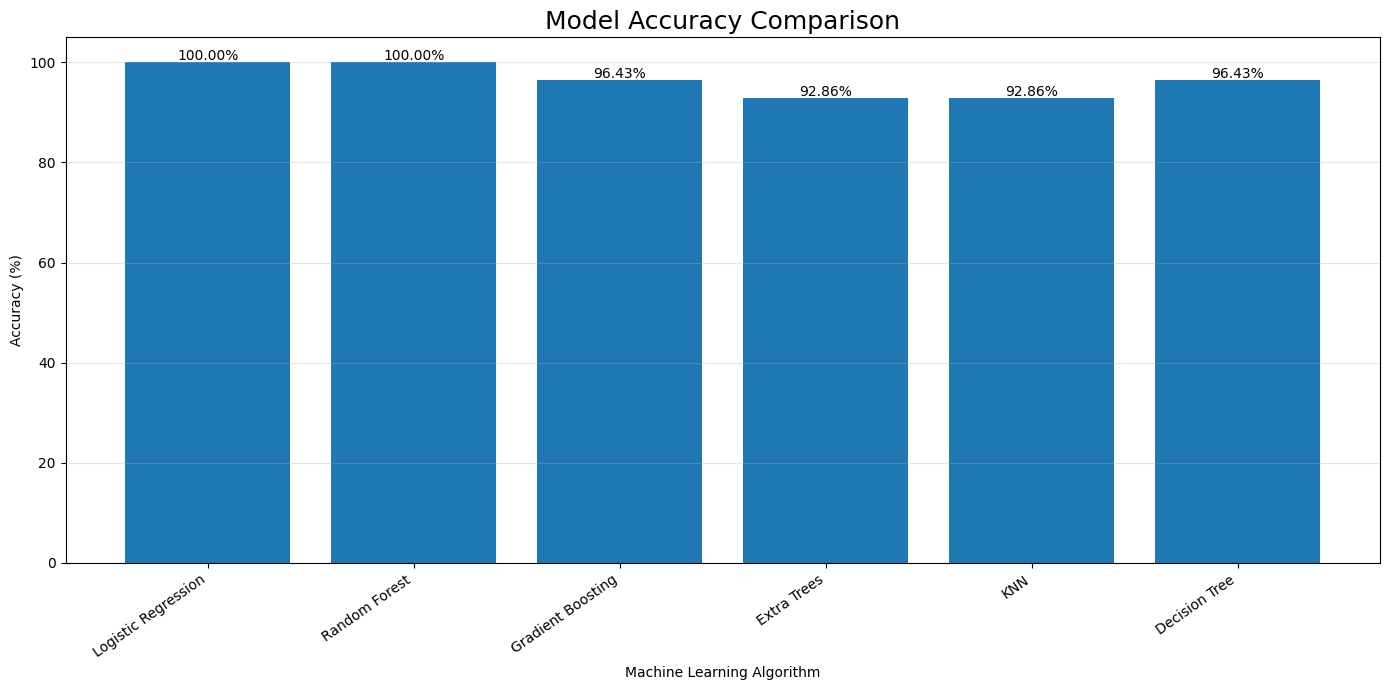

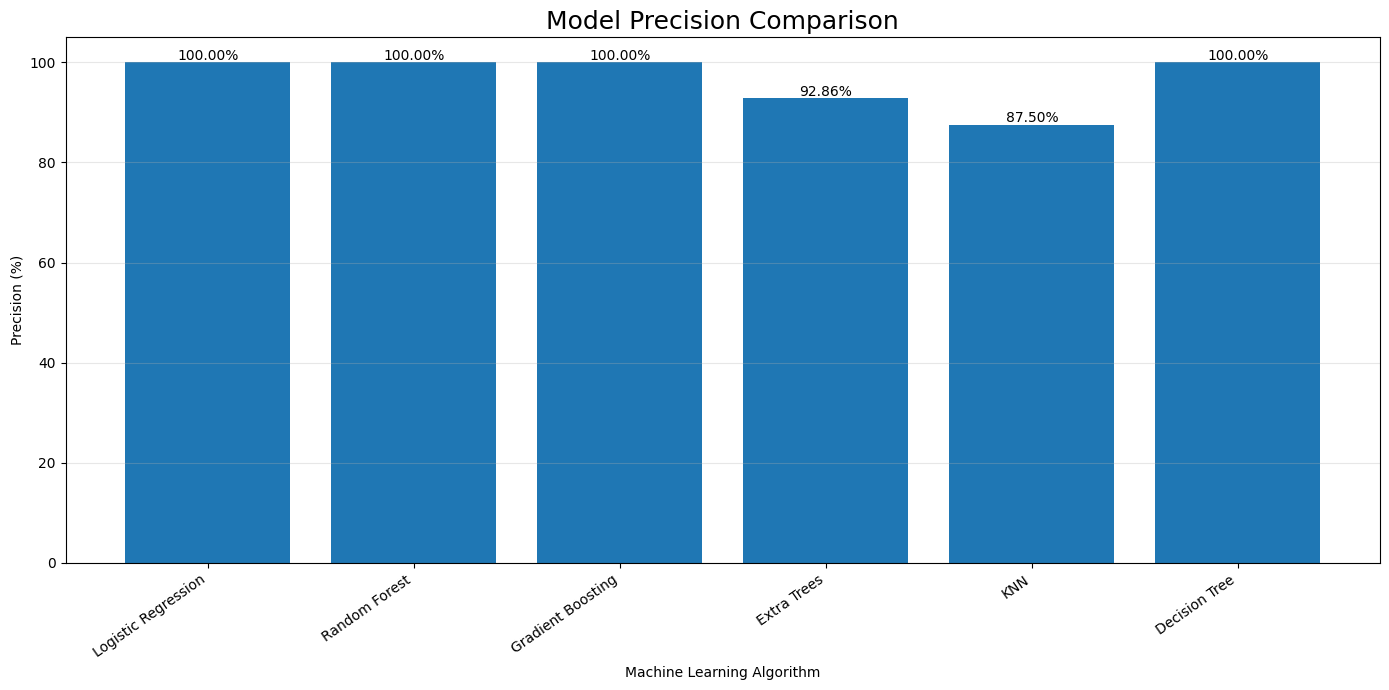

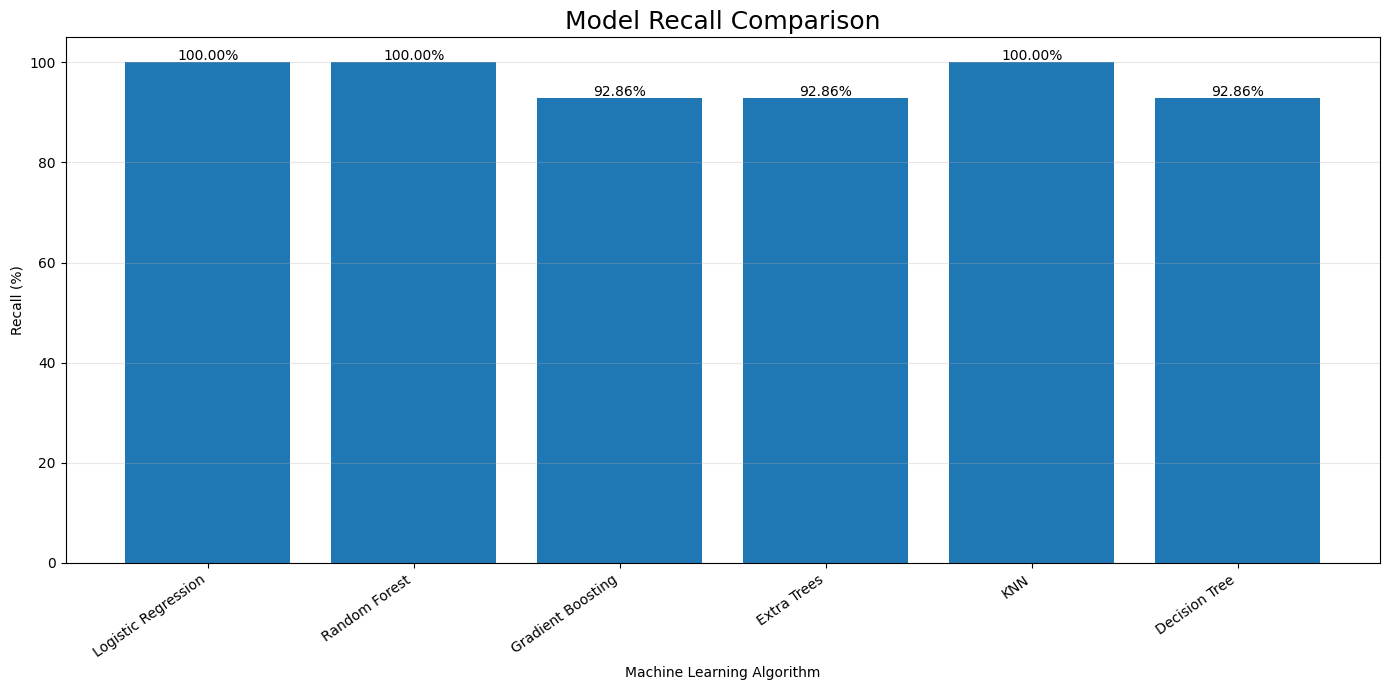

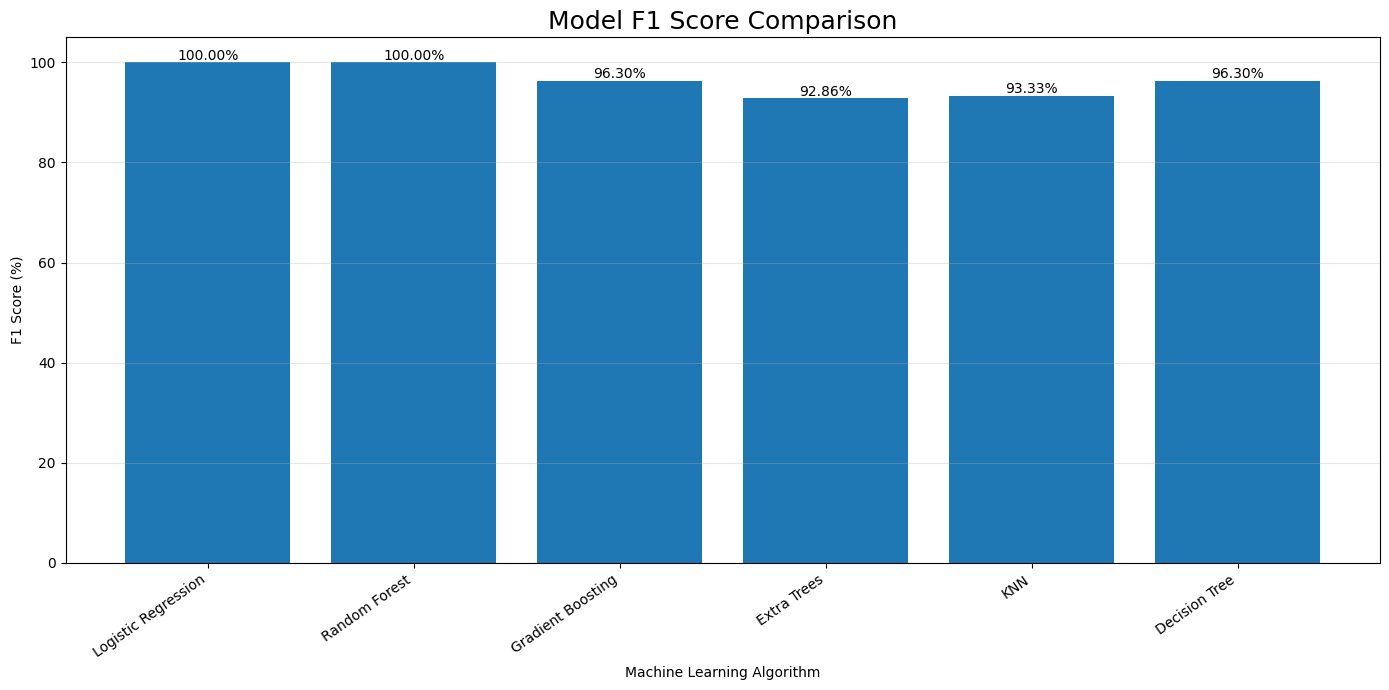

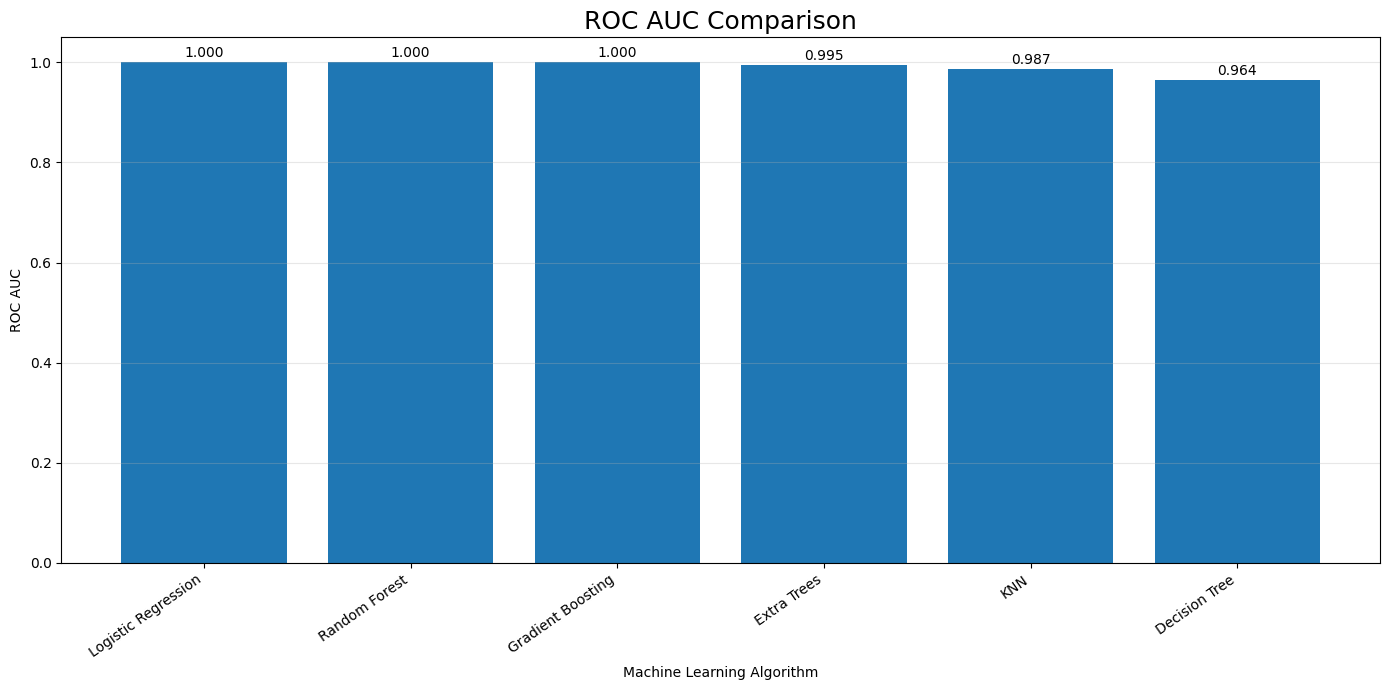

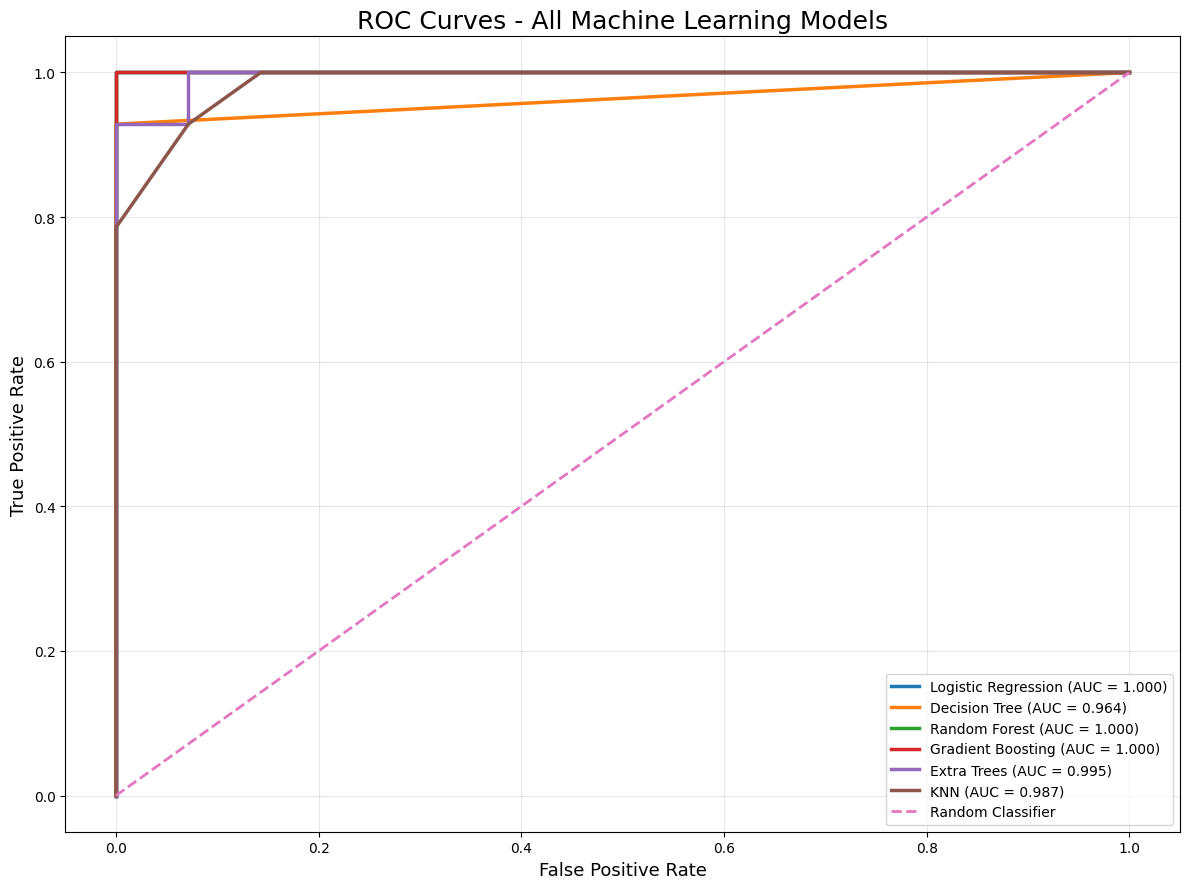

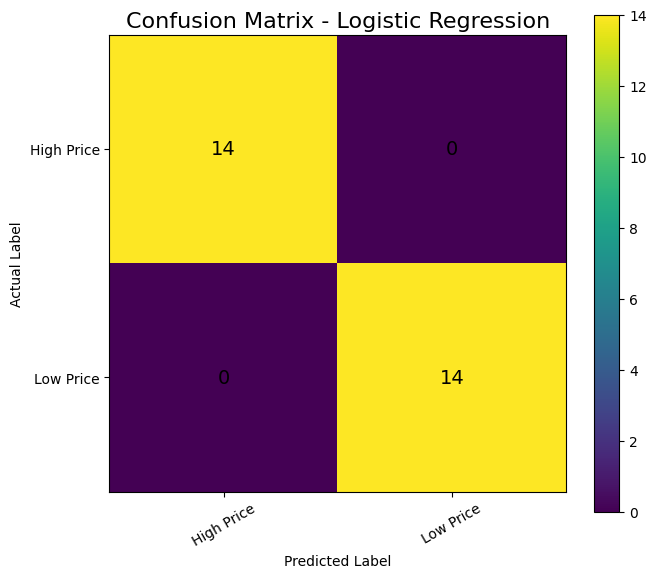

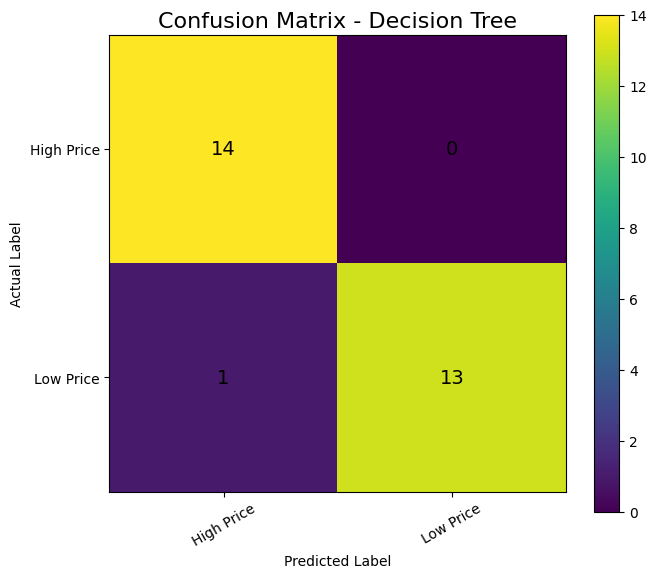

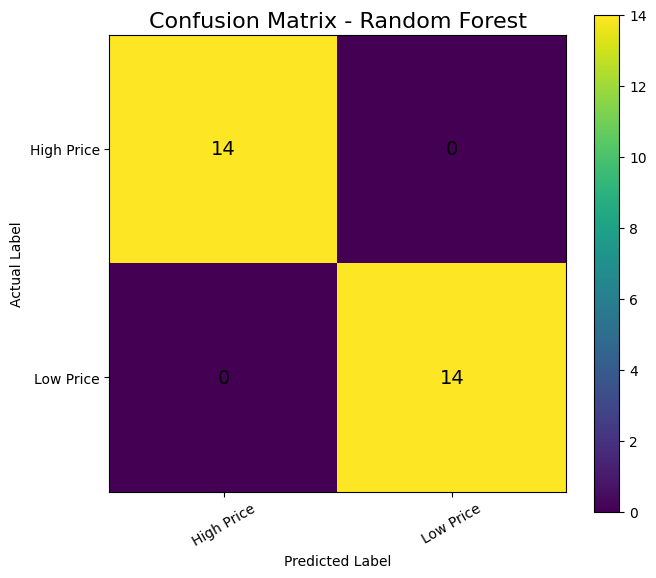

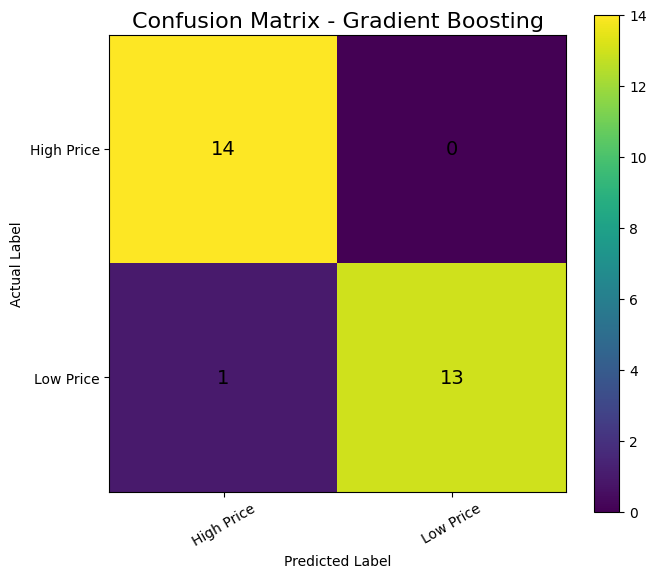

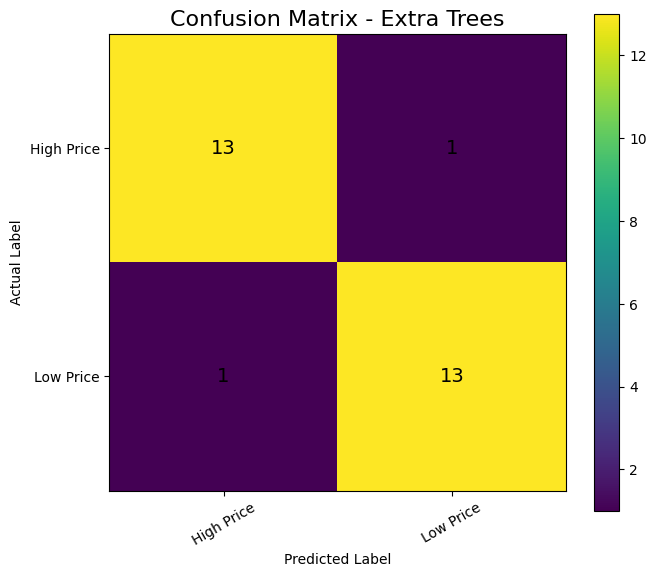

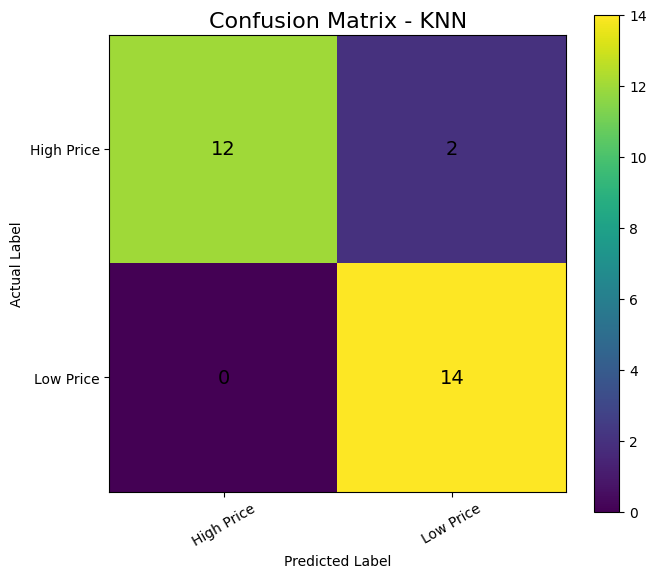

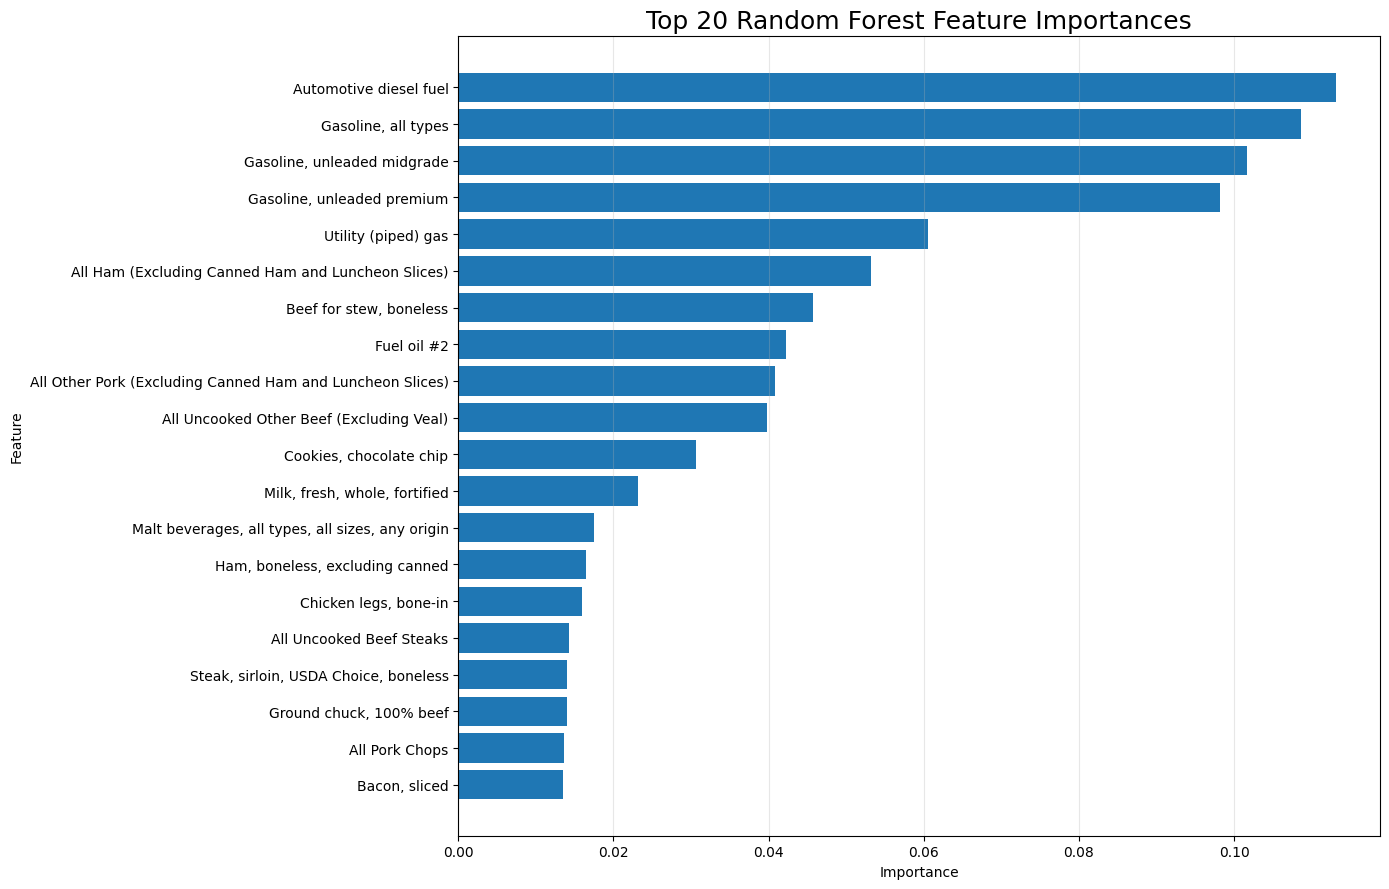



TOP 20 IMPORTANT FEATURES
                                                  Feature  Importance
                                   Automotive diesel fuel    0.113157
                                      Gasoline, all types    0.108669
                              Gasoline, unleaded midgrade    0.101637
                               Gasoline, unleaded premium    0.098202
                                      Utility (piped) gas    0.060605
       All Ham (Excluding Canned Ham and Luncheon Slices)    0.053146
                                  Beef for stew, boneless    0.045761
                                              Fuel oil #2    0.042276
All Other Pork (Excluding Canned Ham and Luncheon Slices)    0.040852
                 All Uncooked Other Beef (Excluding Veal)    0.039745
                                  Cookies, chocolate chip    0.030707
                            Milk, fresh, whole, fortified    0.023181
         Malt beverages, all types, all sizes, any origin    0

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
2,Gradient Boosting,0.9643,1.0000,0.9286,0.9630,1.0000
3,Extra Trees,0.9286,0.9286,0.9286,0.9286,0.9949
4,KNN,0.9286,0.8750,1.0000,0.9333,0.9872
5,Decision Tree,0.9643,1.0000,0.9286,0.9630,0.9643




CLASS INFORMATION
0 = High Price
1 = Low Price

ML classification analysis completed successfully.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


# ================================================================
# 1. COPY DATASET
# ================================================================

df = df_wide.copy()

print("=" * 80)
print("ORIGINAL DATASET")
print("=" * 80)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ================================================================
# 2. DATE PROCESSING
# ================================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Create useful date features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

# Drop original date
df = df.drop(columns=["date"])


# ================================================================
# 3. SELECT TARGET COLUMN
# ================================================================

TARGET = "Gasoline, unleaded regular"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found in df_wide."
    )

print("\n" + "=" * 80)
print("TARGET COLUMN")
print("=" * 80)

print("Target:", TARGET)


# ================================================================
# 4. CREATE BINARY CLASSIFICATION TARGET
# ================================================================

# Convert target to numeric
df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)

# Remove rows where target is missing
df = df.dropna(
    subset=[TARGET]
).reset_index(drop=True)

# Median price
target_median = df[TARGET].median()

print("\nTarget median price:", target_median)

# Create classification target
# 0 = Low Price
# 1 = High Price

df["Price_Class"] = np.where(
    df[TARGET] >= target_median,
    "High Price",
    "Low Price"
)

# Remove original continuous target
df = df.drop(
    columns=[TARGET]
)


# ================================================================
# 5. LABEL ENCODING
# ================================================================

label_encoder = LabelEncoder()

df["Price_Class_Encoded"] = label_encoder.fit_transform(
    df["Price_Class"]
)

print("\n" + "=" * 80)
print("LABEL ENCODING")
print("=" * 80)

print(
    "Class mapping:",
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(
                label_encoder.classes_
            )
        )
    )
)

print("\nEncoded target distribution:")
print(
    df["Price_Class_Encoded"].value_counts()
)


# ================================================================
# 6. CREATE X AND y
# ================================================================

X = df.drop(
    columns=[
        "Price_Class",
        "Price_Class_Encoded"
    ]
)

y = df["Price_Class_Encoded"]


# ================================================================
# 7. MAKE SURE FEATURES ARE NUMERIC
# ================================================================

for col in X.columns:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )


print("\n" + "=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print("Number of features:", X.shape[1])
print("Number of samples :", X.shape[0])


# ================================================================
# 8. TRAIN-TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ================================================================
# 9. HANDLE MISSING VALUES
# ================================================================

imputer = SimpleImputer(
    strategy="median"
)

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


# ================================================================
# 10. FEATURE SCALING
# ================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ================================================================
# 11. DEFINE ML ALGORITHMS
# ================================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7
        )
}


# ================================================================
# 12. TRAIN MODELS
# ================================================================

results = []

trained_models = {}

roc_data = {}


for model_name, model in models.items():

    print("\n")
    print("=" * 80)
    print("TRAINING:", model_name)
    print("=" * 80)

    # ------------------------------------------------------------
    # Use scaled data for Logistic Regression and KNN
    # ------------------------------------------------------------

    if model_name in [
        "Logistic Regression",
        "KNN"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        y_probability = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

        y_probability = model.predict_proba(
            X_test
        )[:, 1]


    # Save model
    trained_models[
        model_name
    ] = model


    # ------------------------------------------------------------
    # Evaluation metrics
    # ------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc_score = roc_auc_score(
        y_test,
        y_probability
    )


    # ------------------------------------------------------------
    # Store results
    # ------------------------------------------------------------

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": auc_score
    })


    # ------------------------------------------------------------
    # ROC information
    # ------------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    roc_data[model_name] = {

        "fpr": fpr,

        "tpr": tpr,

        "auc": auc_score
    }


    # ------------------------------------------------------------
    # Print results
    # ------------------------------------------------------------

    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {f1 * 100:.2f}%"
    )

    print(
        f"ROC AUC   : {auc_score:.4f}"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )


# ================================================================
# 13. MODEL COMPARISON TABLE
# ================================================================

results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 100)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 100)

print(
    results_df.round(4)
)


# ================================================================
# 14. ACCURACY COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Accuracy (%)")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

# Add values on bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ================================================================
# 15. PRECISION COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["Precision"] * 100
)

plt.title(
    "Model Precision Comparison",
    fontsize=18
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Precision (%)")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 16. RECALL COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["Recall"] * 100
)

plt.title(
    "Model Recall Comparison",
    fontsize=18
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("Recall (%)")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 17. F1 SCORE COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["F1 Score"] * 100
)

plt.title(
    "Model F1 Score Comparison",
    fontsize=18
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("F1 Score (%)")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 18. ROC AUC COMPARISON
# ================================================================

plt.figure(figsize=(14, 7))

bars = plt.bar(
    results_df["Model"],
    results_df["ROC AUC"]
)

plt.title(
    "ROC AUC Comparison",
    fontsize=18
)

plt.xlabel("Machine Learning Algorithm")
plt.ylabel("ROC AUC")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(0, 1.05)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ================================================================
# 19. ROC CURVE - ALL MODELS
# ================================================================

plt.figure(figsize=(12, 9))

for model_name, values in roc_data.items():

    plt.plot(
        values["fpr"],
        values["tpr"],
        linewidth=2.5,
        label=f"{model_name} (AUC = {values['auc']:.3f})"
    )


# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.title(
    "ROC Curves - All Machine Learning Models",
    fontsize=18
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 20. CONFUSION MATRIX FOR EACH MODEL
# ================================================================

for model_name, model in trained_models.items():

    if model_name in [
        "Logistic Regression",
        "KNN"
    ]:

        predictions = model.predict(
            X_test_scaled
        )

    else:

        predictions = model.predict(
            X_test
        )


    cm = confusion_matrix(
        y_test,
        predictions
    )


    plt.figure(figsize=(7, 6))

    plt.imshow(
        cm,
        interpolation="nearest"
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=16
    )

    plt.colorbar()

    tick_marks = np.arange(
        len(label_encoder.classes_)
    )

    plt.xticks(
        tick_marks,
        label_encoder.classes_,
        rotation=30
    )

    plt.yticks(
        tick_marks,
        label_encoder.classes_
    )

    plt.xlabel(
        "Predicted Label"
    )

    plt.ylabel(
        "Actual Label"
    )


    # Display values
    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=14
            )


    plt.tight_layout()
    plt.show()


# ================================================================
# 21. FEATURE IMPORTANCE - RANDOM FOREST
# ================================================================

random_forest = trained_models[
    "Random Forest"
]

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        random_forest.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(20)
)


plt.figure(figsize=(14, 9))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.title(
    "Top 20 Random Forest Feature Importances",
    fontsize=18
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ================================================================
# 22. FEATURE IMPORTANCE TABLE
# ================================================================

print("\n")
print("=" * 80)
print("TOP 20 IMPORTANT FEATURES")
print("=" * 80)

print(
    feature_importance.to_string(
        index=False
    )
)


# ================================================================
# 23. FINAL MODEL RESULTS
# ================================================================

print("\n")
print("=" * 100)
print("FINAL MODEL PERFORMANCE")
print("=" * 100)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC AUC": "{:.4f}"
    })
)


# ================================================================
# 24. FINAL CLASS INFORMATION
# ================================================================

print("\n")
print("=" * 80)
print("CLASS INFORMATION")
print("=" * 80)

for encoded, original in enumerate(
    label_encoder.classes_
):

    print(
        f"{encoded} = {original}"
    )


print("\nML classification analysis completed successfully.")

## Thank you..pls upvote!!!!!!!!!!
